In [318]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r'D:\Shorya\python\EDA Practice csv\WineQT.csv')


### 🍷 Feature Explanations
#### 1. fixed acidity

Acids that don’t evaporate easily (like tartaric acid).
Contribute to the wine’s sour taste and stability.
Higher values → more tart/sour wine.

#### 2. volatile acidity

Acids that evaporate easily (mainly acetic acid).
Too much gives a vinegar-like taste.
High volatile acidity is usually bad for quality.

#### 3. citric acid

Adds freshness and flavor.
Found in small amounts.
Higher levels can improve taste.

#### 4. residual sugar

Sugar left after fermentation.
Higher values = sweeter wine.
Dry wines have low residual sugar.

#### 5. chlorides

Amount of salt in wine.
Too much can make wine taste salty.
Lower is generally better.

#### 6. free sulfur dioxide

SO₂ not yet bound to other molecules.
Prevents bacteria and oxidation.
Acts as a preservative.

#### 7. total sulfur dioxide

Total SO₂ (free + bound).
Protects wine from spoilage.
Too high can affect taste and smell.

#### 8. density

How heavy the wine is compared to water.
Related to sugar and alcohol levels.
More sugar → higher density.

#### 9. pH

Acidity level (0–14 scale).
Wine usually between 3–4.
Lower pH = more acidic.

#### 10. sulphates

Additives that help preserve wine.
Can improve flavor and stability.
Moderate levels are good.

#### 11. alcohol

% of alcohol content.
Often positively linked to quality.
Higher alcohol can mean richer taste.

#### 12. quality

Score given by experts (usually 0–10).
This is your target variable in ML.

#### 13. Id

Just a row identifier.
Not useful for modeling.

In [4]:
df.shape

(1143, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [6]:
df.sample(7)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
419,5.0,0.42,0.24,2.0,0.060,19.0,50.0,0.99170,3.72,0.74,14.0,8,588
530,11.1,0.39,0.54,2.7,0.095,21.0,101.0,1.00010,3.13,0.51,9.5,5,744
206,8.7,0.52,0.09,2.5,0.091,20.0,49.0,0.99760,3.34,0.86,10.6,7,288
99,8.1,0.67,0.55,1.8,0.117,32.0,141.0,0.99680,3.17,0.62,9.4,5,145
573,8.7,0.46,0.31,2.5,0.126,24.0,64.0,0.99746,3.10,0.74,9.6,5,796
1099,6.2,0.52,0.08,4.4,0.071,11.0,32.0,0.99646,3.56,0.63,11.6,6,1540
333,9.6,0.54,0.42,2.4,0.081,25.0,52.0,0.99700,3.20,0.71,11.4,6,471


In [7]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [8]:
df.duplicated().sum()

0

#### No Null Values & no duplicates found

## **Univariate Analysis**

### **Fixed Acidity**

In [12]:
df['fixed acidity'].describe()

count    1143.000000
mean        8.311111
std         1.747595
min         4.600000
25%         7.100000
50%         7.900000
75%         9.100000
max        15.900000
Name: fixed acidity, dtype: float64

<Axes: xlabel='fixed acidity', ylabel='Count'>

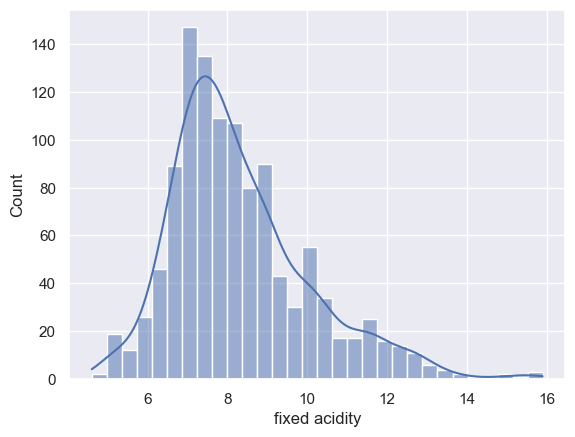

In [13]:
sns.set_style()
sns.set_theme(style='darkgrid')
sns.histplot(x='fixed acidity',data=df,kde=True)

In [14]:
df['fixed acidity'].skew()

1.0449299563724053

The distribution of fixed acidity is right-skewed (1.04), with a mean (8.31) that exceeds the median (7.90). This indicates a concentration of samples in the lower range, pulled upward by high-acidity outliers.

Central Tendency: 50% of the data (IQR) sits tightly between 7.1 and 9.1.

Outlier Influence: The max value (15.9) is more than 4 standard deviations from the mean, representing extreme cases compared to the 4.6 minimum.

Modeling Impact: The skewness suggests that a Log or Box-Cox transformation is necessary for algorithms that assume a normal distribution (e.g., LDA/QDA or Linear Regression).

#### **Volatile Acidity**


<Axes: xlabel='volatile acidity', ylabel='Count'>

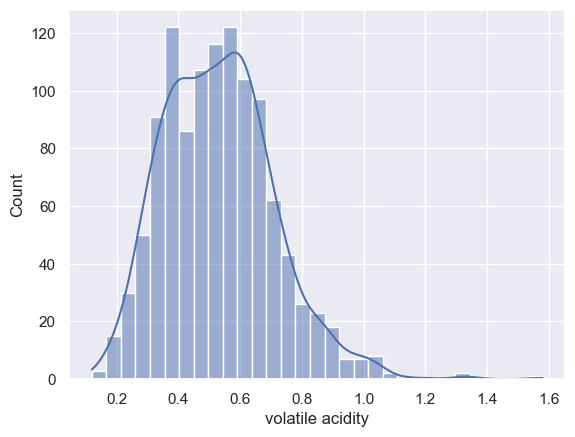

In [17]:
sns.histplot(x='volatile acidity',data=df,kde=True)

In [18]:
df['volatile acidity'].describe()

count    1143.000000
mean        0.531339
std         0.179633
min         0.120000
25%         0.392500
50%         0.520000
75%         0.640000
max         1.580000
Name: volatile acidity, dtype: float64

In [19]:
df['volatile acidity'].skew()

0.6815474143781255

The volatile acidity distribution exhibits moderate right skewness (0.68). The proximity of the mean (0.53) and median (0.52) suggests a more balanced distribution than fixed acidity, though high-end outliers remain present.

Core Range: The IQR (0.39 – 0.64) shows that the majority of wines maintain volatile acidity levels below 0.65, which is typically desired to avoid "vinegary" off-flavors.

Extreme Values: The maximum of 1.58 is nearly 6 standard deviations from the mean, indicating a small subset of samples with exceptionally high acetic acid content.

Modeling Note: While less skewed than other features, the high-end outliers can still disproportionately influence regression weights. A StandardScaler or RobustScaler is recommended to handle these extremes during feature engineering.

In [21]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

### **citric acid**

<Axes: xlabel='citric acid', ylabel='Count'>

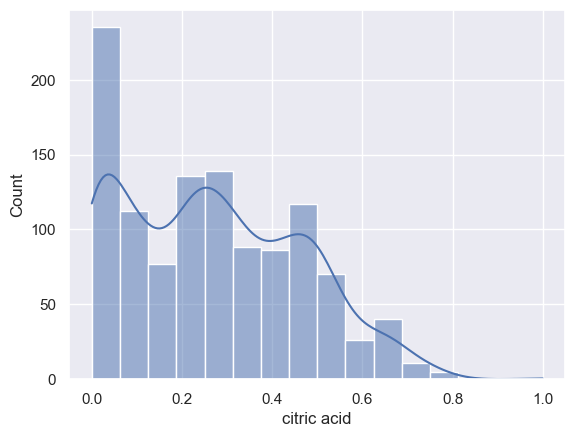

In [23]:
sns.histplot(x='citric acid',data=df,kde=True)

In [24]:
df['citric acid'].skew()

0.3715607833706083

In [25]:
df['citric acid'].describe()

count    1143.000000
mean        0.268364
std         0.196686
min         0.000000
25%         0.090000
50%         0.250000
75%         0.420000
max         1.000000
Name: citric acid, dtype: float64

The citric acid feature shows a slight right skew (0.37), representing one of the most balanced distributions in the dataset. The mean (0.27) and median (0.25) are nearly identical, indicating a relatively symmetric central mass.

Near-Uniformity: The broad IQR (0.09 – 0.42) and a minimum of 0.00 suggest that citric acid is either absent or used in varying amounts to add "freshness" to the wine.

Boundary Constraints: Unlike other acidity metrics, the data is neatly bounded between 0.0 and 1.0. The maximum (1.0) is less of an extreme outlier compared to the volatile acidity scales.

Modeling Impact: Due to its low skewness and clear boundaries, this feature is a strong candidate for Min-Max Scaling. It likely provides a clean signal for classification models without requiring heavy non-linear transformations.

### **residual sugar**

In [28]:
df['residual sugar'].skew()

4.361096404323471

<Axes: xlabel='residual sugar', ylabel='Count'>

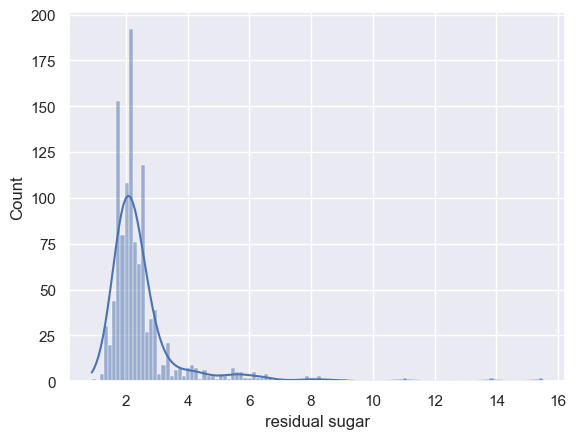

In [29]:
sns.histplot(x='residual sugar',data=df,kde=True)

In [30]:
df['residual sugar'].describe()

count    1143.000000
mean        2.532152
std         1.355917
min         0.900000
25%         1.900000
50%         2.200000
75%         2.600000
max        15.500000
Name: residual sugar, dtype: float64

Residual sugar exhibits an extreme right skew (4.36), making it the most asymmetrical feature in the dataset. While the mean is 2.53, the median of 2.20 provides a more accurate representation of the typical sample.

Extreme Outliers: The maximum value (15.5) is over 9 standard deviations from the mean. This suggests that while most samples are "dry" wines, there are significant outliers representing much sweeter varieties.

Data Compression: 75% of the data (the 3rd quartile) is below 2.6, yet the range extends all the way to 15.5. This indicates a massive "long tail" where a few data points occupy a large portion of the feature space.

Modeling Impact: Because of the 4.36 skewness, raw values will likely degrade the performance of linear models. A Log Transformation or clipping outliers is highly recommended to prevent these few high-sugar samples from dominating the model's loss function.

In [32]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

### **chlorides**

<Axes: xlabel='chlorides', ylabel='Count'>

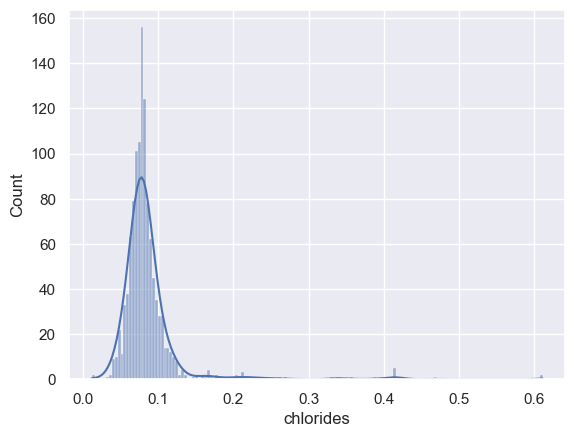

In [34]:
sns.histplot(x='chlorides',data=df,kde=True)

In [35]:
df['chlorides'].skew()

6.026360154399587

In [36]:
df['chlorides'].describe()

count    1143.000000
mean        0.086933
std         0.047267
min         0.012000
25%         0.070000
50%         0.079000
75%         0.090000
max         0.611000
Name: chlorides, dtype: float64

Chlorides (salt content) exhibits extreme right skewness (6.0), the highest in the dataset. While the mean is 0.087, the median of 0.079 is a more stable measure of typical concentration.

Tight Core, Long Tail: 75% of the wines have chloride levels below 0.09, yet the distribution stretches to a maximum of 0.611.

Extreme Outliers: The maximum value is over 11 standard deviations from the mean, indicating a tiny fraction of samples with anomalous salt levels.

Modeling Impact: With a skewness of 6.0, this feature is highly non-normal. Standard scaling will be ineffective due to the extreme range; a Log Transformation or RobustScaler (which uses the IQR) is critical to prevent these outliers from biasing model weights.

### **free sulfur dioxide**

<Axes: xlabel='free sulfur dioxide', ylabel='Count'>

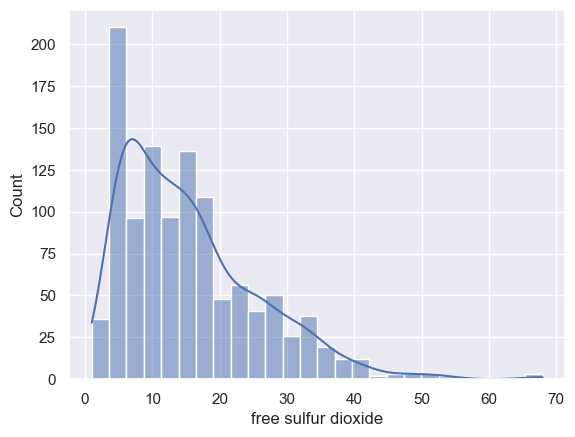

In [39]:
sns.histplot(x='free sulfur dioxide',data=df,kde=True)

In [40]:
df['free sulfur dioxide'].skew()


1.2312611567075427

In [41]:
df['free sulfur dioxide'].describe()

count    1143.000000
mean       15.615486
std        10.250486
min         1.000000
25%         7.000000
50%        13.000000
75%        21.000000
max        68.000000
Name: free sulfur dioxide, dtype: float64

Free sulfur dioxide shows a significant right skew (1.23). The mean (15.62) is notably higher than the median (13.00), indicating that a portion of the samples contains much higher levels of preservatives than the average wine in this set.

Distribution Spread: The IQR (7.0 – 21.0) suggests that the middle 50% of the dataset is relatively concentrated, but the maximum of 68.0 is more than 5 standard deviations from the mean.

Preservation Variance: The minimum of 1.0 vs. the 75th percentile of 21.0 indicates high variability in how these wines are stabilized, which likely correlates with their shelf life or specific wine type (red vs. white).

Modeling Impact: A skewness of 1.23 is high enough to warrant a Square Root or Log Transformation. This will help stabilize the variance, especially if you intend to use distance-based algorithms like K-Nearest Neighbors or clustering.

### **total sulfur dioxide**

<Axes: xlabel='total sulfur dioxide', ylabel='Count'>

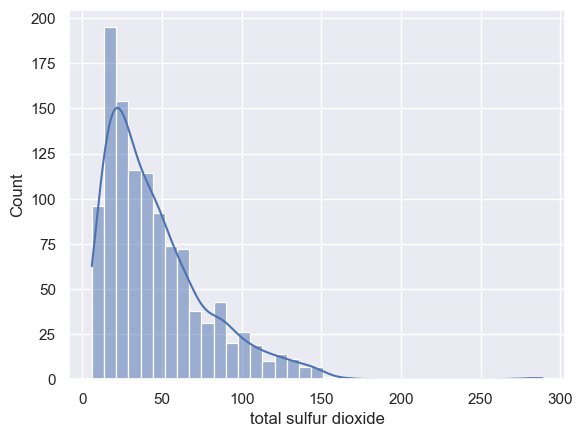

In [44]:
sns.histplot(x='total sulfur dioxide',data=df,kde=True)

In [45]:
df['total sulfur dioxide'].skew()

1.6657660141342994

In [46]:
df['total sulfur dioxide'].describe()

count    1143.000000
mean       45.914698
std        32.782130
min         6.000000
25%        21.000000
50%        37.000000
75%        61.000000
max       289.000000
Name: total sulfur dioxide, dtype: float64

The total sulfur dioxide distribution is strongly right-skewed ($1.66$), indicating a high concentration of wines with low-to-moderate levels and a significant "long tail" of high-preservative samples.Central Mass vs. Outliers: The mean ($45.91$) is substantially higher than the median ($37.00$), driven by extreme values. The maximum ($289.0$) is nearly $7.5$ standard deviations away from the mean, representing extreme outliers.Concentration: $75\%$ of the samples fall below $61.0$, yet the range extends nearly five times that value to $289.0$. This disparity suggests that while most wines are stable with minimal additives, a small subset is heavily treated.Modeling Impact: A skewness of $1.66$ will likely violate the normality assumptions of many statistical models. A Log Transformation or Power Transformation is strongly recommended to compress the tail and improve the performance of linear or distance-based algorithms.

### **density**

<Axes: xlabel='density', ylabel='Count'>

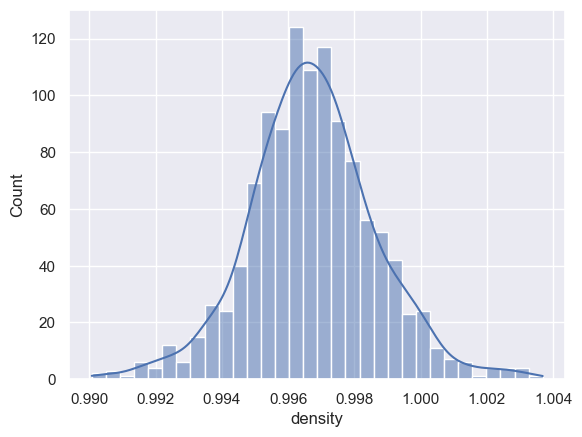

In [49]:
sns.histplot(x='density',kde=True,data=df)

In [50]:
df['density'].skew()

0.102395108720599

In [51]:
df['density'].describe()

count    1143.000000
mean        0.996730
std         0.001925
min         0.990070
25%         0.995570
50%         0.996680
75%         0.997845
max         1.003690
Name: density, dtype: float64

Density exhibits a near-normal distribution with a negligible skew of 0.10. This is the most statistically "stable" feature in the dataset, characterized by extremely low variance.

High Precision, Low Spread: The Standard Deviation (0.0019) is remarkably small. Most values are tightly clustered around the mean (0.9967) and median (0.9966), reflecting the physical properties of wine, which typically hover near the density of water.

Symmetry: Because the skewness is near zero, the distribution is almost perfectly symmetrical. The minimum (0.990) and maximum (1.003) are roughly equidistant from the mean, suggesting an absence of the extreme outliers seen in the acidity or sugar features.

Modeling Impact: This feature is an excellent candidate for Standardization (Z-score scaling). Unlike the high-skew variables in this dataset, density requires no non-linear transformations and can be used directly in models that assume normality.

In [53]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

### **pH**

<Axes: xlabel='pH', ylabel='Count'>

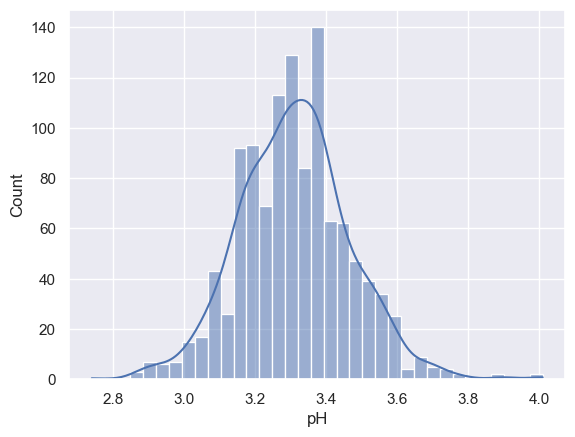

In [55]:
sns.histplot(x='pH',data=df,kde=True)

In [56]:
df['pH'].skew()

0.22113839209685748

In [57]:
df['pH'].describe()

count    1143.000000
mean        3.311015
std         0.156664
min         2.740000
25%         3.205000
50%         3.310000
75%         3.400000
max         4.010000
Name: pH, dtype: float64

The pH level exhibits a near-perfect normal distribution with a skewness of approximately 0.11. The mean (3.311) and median (3.310) are nearly identical, indicating high symmetry in the data.

Tight Distribution: A very low standard deviation (0.15) shows that acidity levels are highly controlled. Most wines (IQR) fall within a narrow band between 3.20 and 3.40.

Controlled Range: The values are well-bounded between a minimum of 2.74 and a maximum of 4.01. This reflects the biological and chemical constraints of winemaking, where pH must remain within a specific range to ensure stability and prevent spoilage.

Modeling Impact: Like density, this feature is ideal for Standardization (Z-score). It requires no transformation and provides a very clean, normally distributed signal for classification and regression tasks.

### **sulphates**

<Axes: xlabel='sulphates', ylabel='Count'>

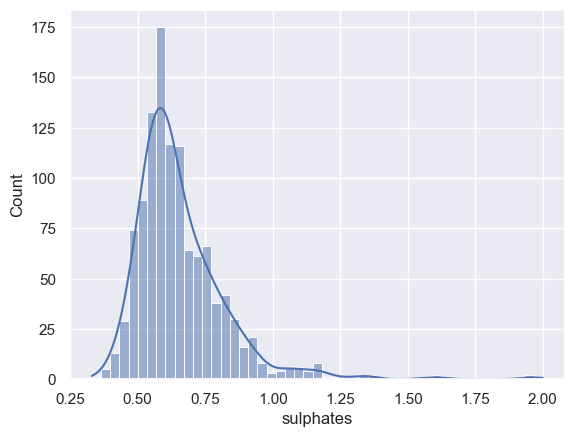

In [60]:
sns.histplot(x='sulphates',data=df,kde=True)

In [61]:
df['sulphates'].skew()

2.497266051332364

In [62]:
df['sulphates'].describe()

count    1143.000000
mean        0.657708
std         0.170399
min         0.330000
25%         0.550000
50%         0.620000
75%         0.730000
max         2.000000
Name: sulphates, dtype: float64

The sulphates distribution is strongly right-skewed ($2.2$), indicating that while most wines have a consistent level of additives, a small group of samples contains significantly higher concentrations.

Central Tendency: The mean ($0.66$) is pulled above the median ($0.62$) by the upper tail. The majority of the data (IQR) is tightly packed between $0.55$ and $0.73$.Outlier Profile: The maximum value of $2.00$ is an extreme outlier, sitting nearly $8$ standard deviations away from the mean. These high-sulphate wines are rare but likely represent a distinct sub-category in the dataset.

Modeling Impact: A skewness of $2.2$ is high enough to distort models like Linear Regression or LDA. Applying a Log Transformation or Square Root Transformation is essential to normalize the feature and prevent the extreme upper values from exerting undue influence on the model’s coefficients.

### **alcohol**

<Axes: xlabel='alcohol', ylabel='Count'>

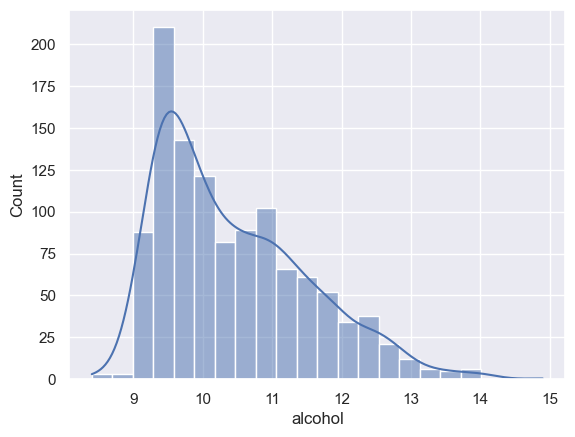

In [65]:
sns.histplot(x='alcohol',data=df,kde=True)

In [66]:
df['alcohol'].skew()

0.8633132317223615

In [67]:
df['alcohol'].describe()

count    1143.000000
mean       10.442111
std         1.082196
min         8.400000
25%         9.500000
50%        10.200000
75%        11.100000
max        14.900000
Name: alcohol, dtype: float64

The alcohol content exhibits a moderate right skew (0.86). While not as extreme as the acidity or sugar metrics, the distribution shows that higher-alcohol wines are less frequent, pulling the mean (10.44) slightly above the median (10.20).

Typical Range: The IQR (9.5 – 11.1) indicates that the majority of wines in this dataset fall within a standard 1.6% alcohol-by-volume (ABV) band.

Distributional Spread: The data is well-bounded between a minimum of 8.4 and a maximum of 14.9. Unlike other features, the maximum value is roughly 4 standard deviations from the mean, representing a significant but realistic upper limit for naturally fermented wines.

Modeling Impact: A skewness of 0.86 is on the boundary of needing transformation. While linear models may handle it reasonably well, a Log or Square Root transformation could help if you aim to achieve a more Gaussian shape for algorithms sensitive to normality.

### **quality**

<Axes: xlabel='quality', ylabel='count'>

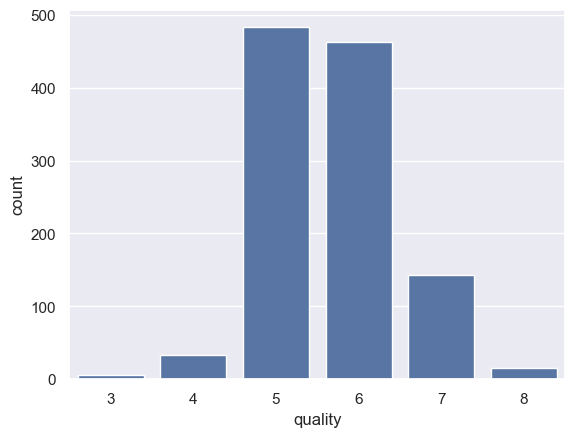

In [70]:
sns.countplot(x='quality',data=df)

In [71]:
df['quality'].value_counts(normalize=True)*100

quality
5    42.257218
6    40.419948
7    12.510936
4     2.887139
8     1.399825
3     0.524934
Name: proportion, dtype: float64

The quality rating exhibits a significant class imbalance, with the data heavily concentrated in the middle-tier categories.Dominant Classes: Over $82\%$ of the wines are rated either 5 ($42.3\%$) or 6 ($40.4\%$). This indicates that the dataset is primarily composed of "average" wines.

Extreme Scarcity: The extreme ends of the spectrum are rare. Quality 3 and 8 combined represent less than $2\%$ of the dataset, making it difficult for models to learn the specific characteristics of the best and worst wines.

Modeling Impact: This distribution creates a high risk of class bias. A model may achieve high accuracy by simply predicting the majority classes (5 and 6) while failing to identify high-quality wines (7 and 8). To counter this, consider using stratified sampling, class weighting, or SMOTE (Synthetic Minority Over-sampling Technique) during the training phase.

## **Univariate Analysis Summary**


### **Univariate Analysis Summary — Wine Quality Dataset**

The univariate exploration reveals a dataset dominated by **asymmetry, outliers, and varying levels of statistical stability across features**, which directly influences downstream modeling choices.

A clear pattern emerges among the chemical composition variables—**most acidity-related features (fixed acidity, volatile acidity, residual sugar, chlorides, sulfur dioxide, sulphates)** exhibit **right-skewed distributions**, often with long tails driven by extreme values. For instance, fixed acidity and residual sugar show strong skewness, indicating that while most wines fall within a controlled lower range, a small subset of samples carries disproportionately high values. These outliers are not just statistical artifacts—they likely represent **distinct wine styles (e.g., sweeter or heavily preserved wines)** rather than noise.

In contrast, features like **citric acid** maintain a relatively balanced distribution, suggesting a more uniform application in winemaking. Even more stable are **density and pH**, both of which closely follow a normal distribution with minimal variance. These variables reflect the **physical and chemical constraints of wine production**, where extreme deviations are naturally limited. As a result, they provide **clean, reliable signals** for modeling without requiring heavy preprocessing.

Some variables, such as **chlorides and residual sugar**, stand out for their **extreme skewness and long-tailed behavior**, where a very small number of observations occupy a disproportionately large feature space. This creates a risk: if left untreated, these values can **dominate model training**, especially in linear or distance-based algorithms, leading to biased or unstable predictions.

Alcohol content and volatile acidity sit in a middle ground—**moderately skewed but still manageable**, indicating realistic variation across wine samples without extreme distortion. These features may not strictly require transformation but could benefit from mild normalization depending on the model choice.

A particularly important observation comes from the **target variable (quality)**. The ratings are heavily concentrated around mid-range values (primarily 5 and 6), with very few samples at the extremes. This imbalance highlights a real-world truth: **most wines are average**, while truly exceptional or poor-quality wines are rare. However, from a modeling perspective, this creates a challenge—models may become biased toward predicting the majority classes while struggling to identify high-quality wines.

---

### **Key Insights & Modeling Implications**

* The dataset is **not naturally Gaussian**—many features violate normality assumptions due to skewness and outliers.
* **Log, Box-Cox, or square root transformations** will be critical for heavily skewed variables like residual sugar, chlorides, and sulfur dioxide.
* **Robust scaling techniques** are preferred over standard scaling for features with extreme outliers.
* Naturally stable features like **pH and density** can be used directly with minimal preprocessing, making them highly reliable predictors.
* The **long-tailed distributions** hint at hidden subgroups (e.g., sweet vs. dry wines), suggesting potential for clustering or segmentation.
* The **class imbalance in quality** is a major modeling concern—without correction, models will favor “average” predictions and miss high-quality wines.

---

### **Final Takeaway**

This dataset tells a very real story about wine:
most bottles are consistent and predictable, but a few stand out—either exceptionally refined or chemically distinct. From a data science perspective, our job isn’t just to model the average—it’s to **handle the extremes carefully**, because that’s where both the **risk and the insight** lie.



## **Bivariate Analysis**

In [75]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

### **fixed acidity vs Quality**

<Axes: xlabel='quality', ylabel='fixed acidity'>

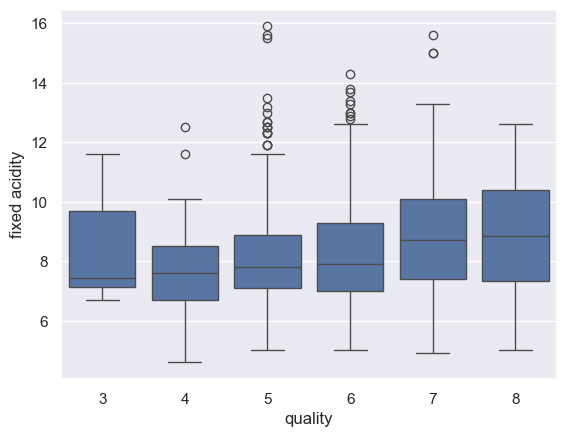

In [77]:
sns.boxplot(x='quality',y='fixed acidity',data=df)

In [78]:
df.groupby('quality')['fixed acidity'].agg(['min','max','mean','median','std'])

,min,max,mean,median,std
quality,,,,,
3,6.7,11.6,8.450000,7.45,2.032486
4,4.6,12.5,7.809091,7.60,1.685668
5,5.0,15.9,8.161077,7.80,1.557746
6,5.0,14.3,8.317749,7.90,1.771585
7,4.9,15.6,8.851049,8.70,2.105187
8,5.0,12.6,8.806250,8.85,2.089168


fixed acidity is a fundamental structural component that differentiates quality tiers. While the overall dataset is right-skewed, the behavior of this feature across quality scores reveals a clear upward shift in the "baseline" acidity required for premium wines.

**Bivariate Insight:Fixed Acidity vs. Quality**

Ascending Central Tendency: There is a consistent upward trend in the median ($7.45 \rightarrow 8.85$) as quality increases. This suggests that higher-quality wines generally possess a more robust acidic backbone, which provides the "structure" and "lift" found in top-tier ratings.

**The "Quality 7" Peak:** Interestingly, Quality 7 wines show the highest mean (8.85) and median (8.70), even slightly exceeding Quality 8. This indicates that a specific high-acidity threshold may be a key differentiator for moving from "average" (5/6) to "excellent" (7).

**Variance in Premium Tiers:** High-quality wines (7 and 8) show the highest standard deviations ($\approx 2.10$). This implies that while premium wines lean toward higher acidity, they also exhibit more diversity in their chemical profiles compared to lower-rated wines, which are more tightly clustered at lower acidity levels.

### **volatile acidity vs quality**

<Axes: xlabel='quality', ylabel='volatile acidity'>

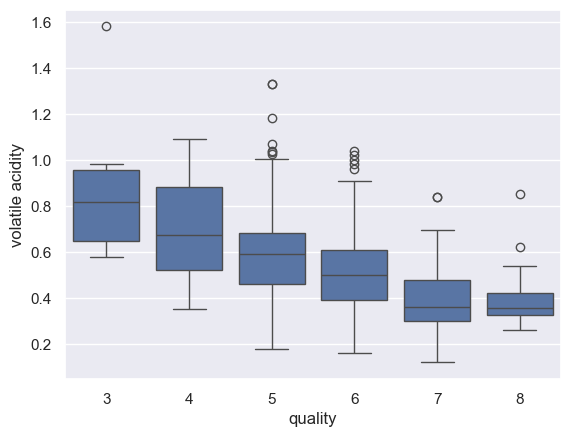

In [81]:
sns.boxplot(x='quality',y='volatile acidity',data=df)

In [82]:
df.groupby('quality')['volatile acidity'].agg(['min','max','mean','median','std'])

,min,max,mean,median,std
quality,,,,,
3,0.58,1.58,0.897500,0.8175,0.367556
4,0.35,1.09,0.700000,0.6750,0.216373
5,0.18,1.33,0.585280,0.5900,0.168226
6,0.16,1.04,0.504957,0.5000,0.159649
7,0.12,0.84,0.393671,0.3600,0.133795
8,0.26,0.85,0.410000,0.3550,0.147919


Bivariate Insight: Volatile Acidity vs. Quality
The statistics for volatile acidity (acetic acid) reveal a clear, inverse relationship with wine quality. This is the structural opposite of your "fixed acidity" finding: as quality increases, volatile acidity levels consistently drop.

Negative Correlation with Excellence: The mean and median values show a steady decline as you move from Quality 3 to Quality 7. For instance, the median drops from 0.81 (Quality 3) to 0.36 (Quality 7). High volatile acidity is chemically associated with vinegar-like aromas, which is clearly penalized in quality scoring.

Quality 8 Plateau: Interestingly, the trend stabilizes between Quality 7 and 8. Quality 8 wines actually show a slightly higher mean (0.41) but a lower median (0.355) than Quality 7. This suggests that while a "clean" profile (low volatile acidity) is necessary to reach the top tiers, the very highest-rated wines might tolerate a tiny bit more variance for complexity.

Tightening Variance: The Standard Deviation (std) decreases as quality improves. Lower-quality wines (Quality 3) have a high spread (0.36), meaning some are extremely "vinegary." High-quality wines (Quality 7/8) have much tighter spreads (~0.14), indicating that low volatile acidity is a strict requirement for a premium rating.

### **citric acid vs quality**

<Axes: xlabel='quality', ylabel='citric acid'>

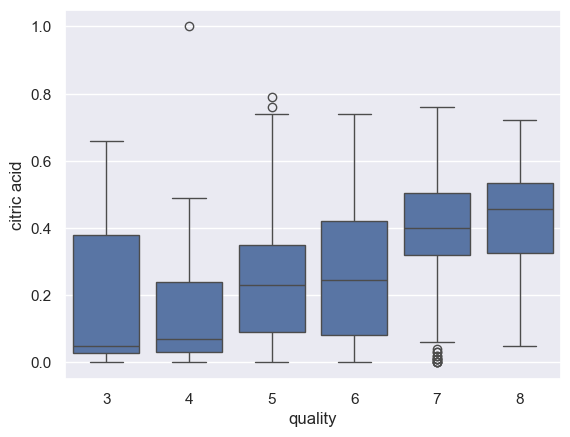

In [85]:
sns.boxplot(x='quality',y='citric acid',data=df)

In [86]:
df.groupby('quality')['citric acid'].agg(['min','max','mean','median','std'])

,min,max,mean,median,std
quality,,,,,
3,0.00,0.66,0.211667,0.050,0.287153
4,0.00,1.00,0.165758,0.070,0.211335
5,0.00,0.79,0.240124,0.230,0.179700
6,0.00,0.74,0.263680,0.245,0.195371
7,0.00,0.76,0.386573,0.400,0.197812
8,0.05,0.72,0.432500,0.455,0.168977


Bivariate Insight: Citric Acid vs. Quality
The analysis of citric acid reveals a strong positive association with quality, reinforcing the "acidic structure" theme. While fixed acidity provides the backbone, citric acid—often associated with "freshness" and "brightness"—acts as a clear differentiator for premium wines.

Linear Progression of Freshness: There is a consistent and significant increase in the median value as quality climbs, nearly doubling from 0.23 (Quality 5) to 0.455 (Quality 8). This suggests that citric acid is a primary driver in moving a wine from "average" to "exceptional."

The "Absence" Penalty: In the lowest quality tier (Quality 3), the median is a staggering 0.05, with a mean of 0.21. This indicates that many low-quality wines completely lack citric acid (minimum of 0.00), likely resulting in a "flat" or "flabby" taste profile.

Tightening Standards at the Top: As quality increases, the distribution becomes more focused. Quality 8 wines not only have the highest median but also the lowest minimum (0.05), suggesting that a baseline level of citric acidity is almost a prerequisite for an elite rating.

### **residual sugar vs quality**

<Axes: xlabel='quality', ylabel='residual sugar'>

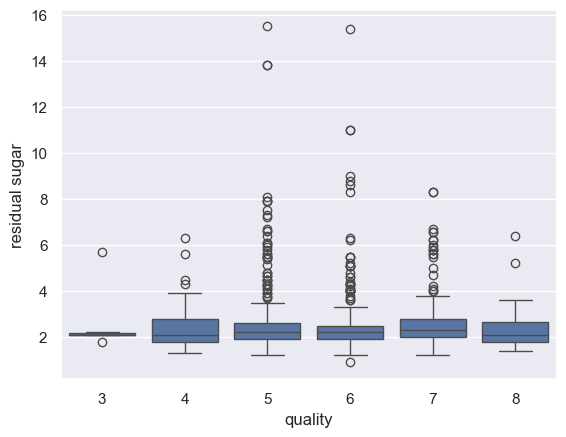

In [89]:
sns.boxplot(x='quality',y='residual sugar',data=df)

In [90]:
df.groupby('quality')['residual sugar'].agg(['min','max','mean','median','std'])

,min,max,mean,median,std
quality,,,,,
3,1.8,5.7,2.666667,2.1,1.492202
4,1.3,6.3,2.566667,2.1,1.190238
5,1.2,15.5,2.540476,2.2,1.436499
6,0.9,15.4,2.444805,2.2,1.256055
7,1.2,8.3,2.760140,2.3,1.409444
8,1.4,6.4,2.643750,2.1,1.360377


Bivariate Insight: Residual Sugar vs. QualityThe statistics for residual sugar reveal that it is one of the least discriminative features for wine quality. Unlike the acidity metrics, sugar levels remain remarkably flat across all quality tiers.Stable Central Tendency: The median sugar level is nearly identical for every quality score, hovering tightly between $2.1$ and $2.3$. This suggests that sweetness is not a primary factor used to distinguish between average and premium wines in this dataset.Ubiquitous Outliers: Extreme maximum values (up to $15.5$) appear in the middle-quality tiers (5 and 6), but the high-quality wines (7 and 8) stay within a more modest range (max $8.3$ and $6.4$). This implies that while outliers exist, "dessert-level" sugar concentrations are rarely found in the highest-rated samples.Low Information Gain: Because the distributions (means and medians) almost perfectly overlap across all classes, residual sugar likely offers very little predictive power for classification models. It acts as a background constant rather than a quality driver.

In [92]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

### **chlorides vs quality**

<Axes: xlabel='quality', ylabel='chlorides'>

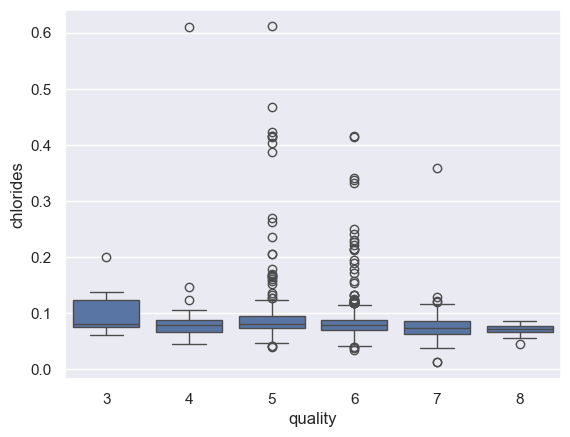

In [94]:
sns.boxplot(x='quality',y='chlorides',data=df)

In [95]:
df.groupby('quality')['chlorides'].agg(['min','max','mean','median','std'])

,min,max,mean,median,std
quality,,,,,
3,0.061,0.200,0.105333,0.0800,0.053298
4,0.045,0.610,0.094788,0.0780,0.094873
5,0.039,0.611,0.091770,0.0810,0.052325
6,0.034,0.415,0.085281,0.0785,0.040465
7,0.012,0.358,0.075217,0.0730,0.030519
8,0.045,0.086,0.070187,0.0715,0.010521


Bivariate Insight: Chlorides vs. Quality
The statistics for chlorides (salt content) reveal a clear "purity" requirement for high-quality wine. Similar to volatile acidity, there is a distinct inverse relationship: as quality increases, chloride levels decrease and become significantly more consistent.

The "Saltiness" Penalty: Both the mean and median values trend downward as quality improves. High-quality wines (Quality 7 and 8) have the lowest median chloride levels (0.073 and 0.0715, respectively). In contrast, lower-rated wines show higher concentrations, suggesting that excess saltiness is perceived as a flavor defect.

Extreme Standardization at the Top: The most striking find is the Standard Deviation (std). While lower-quality tiers have high variance (up to 0.09), Quality 8 wines have an extremely tight spread of 0.0105. This indicates that a very specific, low range of chloride content is a non-negotiable hallmark of premium wines.

Outlier Sensitivity: The maximum values drop sharply from 0.61 in average wines to just 0.086 in Quality 8 wines. This suggests that while a "faulty" batch with high salt can still be rated as a 5 or 6, it is effectively disqualified from reaching the highest ratings.

### **free sulfur dioxide vs quality**

<Axes: xlabel='quality', ylabel='free sulfur dioxide'>

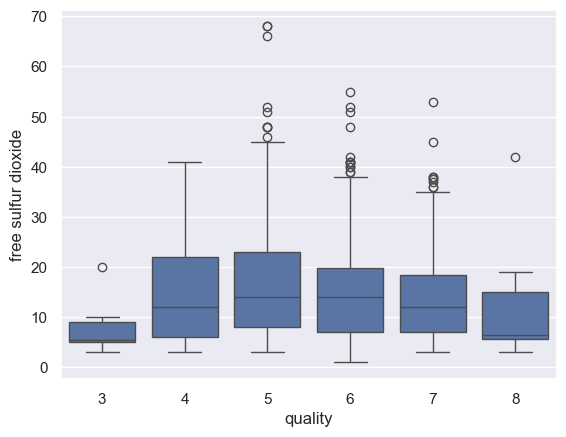

In [98]:
sns.boxplot(x='quality',y='free sulfur dioxide',data=df)

In [99]:
df.groupby('quality')['free sulfur dioxide'].agg(['min','max','mean','median','std'])

,min,max,mean,median,std
quality,,,,,
3,3.0,20.0,8.166667,5.5,6.242329
4,3.0,41.0,14.848485,12.0,10.198410
5,3.0,68.0,16.612836,14.0,10.960945
6,1.0,55.0,15.215368,14.0,9.526174
7,3.0,53.0,14.538462,12.0,9.904842
8,3.0,42.0,11.062500,6.5,9.629598


Bivariate Insight: Free Sulfur Dioxide vs. Quality
The analysis of free sulfur dioxide (preservative) reveals a non-linear, bell-shaped relationship with quality. Unlike the linear trends seen in acidity or chlorides, the highest concentrations of this preservative are found in the middle-quality tiers.

Mid-Tier Peak: Both the mean (16.61) and median (14.0) peak at Quality 5 and then gradually decline as quality improves. This suggests that while a certain amount of preservation is necessary for stability, higher-quality wines might rely on other factors (like alcohol or acidity) for shelf-life, or they are crafted to minimize chemical additives.

Low Concentration at the Extremes: The lowest median values are found in the extreme tiers: Quality 3 (5.5) and Quality 8 (6.5). For Quality 3, a lack of preservative might contribute to the poor quality (spoilage), while for Quality 8, it may reflect a more "natural" or premium production style where excessive sulfites are avoided.

High Variability (High std): The standard deviation is high across the board, often nearly as large as the mean itself. This indicates that within every quality level, there is a massive range of preservation strategies being used, making this feature a "noisy" predictor on its own.

The "Goldilocks" Preservation Theory
This data suggests a "just right" zone for free sulfur dioxide. Too little (Quality 3) may lead to instability, but moving into the premium tiers (7 and 8) requires a reduction in these additives to maintain the pure flavor profile of the fruit

### **total sulfur dioxide vs quality**

<Axes: xlabel='quality', ylabel='total sulfur dioxide'>

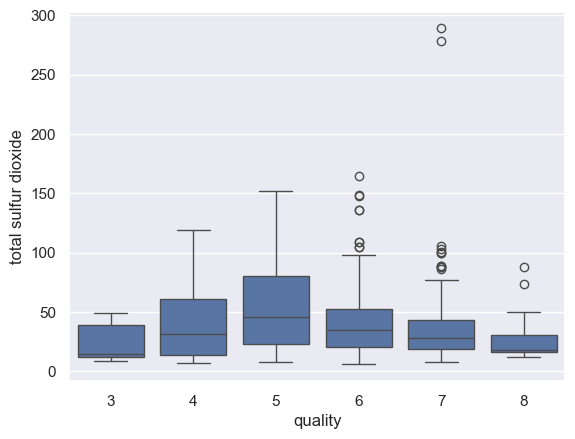

In [102]:
sns.boxplot(x='quality',y='total sulfur dioxide',data=df)

In [103]:
df.groupby('quality')['total sulfur dioxide'].agg(['min','max','mean','median','std'])

,min,max,mean,median,std
quality,,,,,
3,9.0,49.0,24.500000,15.0,18.360283
4,7.0,119.0,40.606061,32.0,28.487870
5,8.0,152.0,55.299172,46.0,36.548411
6,6.0,165.0,39.941558,35.0,24.605231
7,8.0,289.0,37.489510,28.0,36.743279
8,12.0,88.0,29.375000,18.0,22.700587


Bivariate Insight: Total Sulfur Dioxide vs. QualityThe statistics for total sulfur dioxide mirror the "bell-shaped" trend seen in free sulfur dioxide, but with even more pronounced variance and extreme outliers. This feature represents both the free and the bound portions of the preservative.The "Average Wine" Peak: Total sulfur dioxide levels peak at Quality 5, with a mean of $55.30$ and a median of $46.0$. This suggests that mass-market or "average" wines often utilize higher total concentrations of sulfites to ensure stability and shelf-life.The "Clean" Premium Profile: Similar to the acidity and chloride findings, high-quality wines (7 and 8) show a marked decrease in total sulfur dioxide. Quality 8 wines have a median of only $18.0$, nearly the same as the lowest-rated wines (Quality 3). This indicates that elite wines either require less chemical intervention or are crafted with a "minimalist" preservation approach.Massive Outliers: There is a significant outlier in the Quality 7 tier with a maximum of $289.0$, which is nearly $8$ times the mean for that category. This highlights that while the general trend for high quality is "low sulfur," anomalous batches with very high preservation still exist.Predictive Noise: Because the distributions for high-quality (8) and low-quality (3) wines overlap significantly at the lower end of the scale, this feature alone cannot easily distinguish "great" from "poor." It is most effective at identifying the "average" (Quality 5) tier.Synthesis: The Sulfur StoryWe now see a consistent pattern with preservatives:Low Quality (3/4): Low levels (potentially leading to instability/spoilage).Average Quality (5/6): High levels (maximum use of additives for stability).High Quality (7/8): Low levels (likely relying on better fruit quality and natural acidity for preservation).

In [105]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

### **density vs quality**

<Axes: xlabel='quality', ylabel='density'>

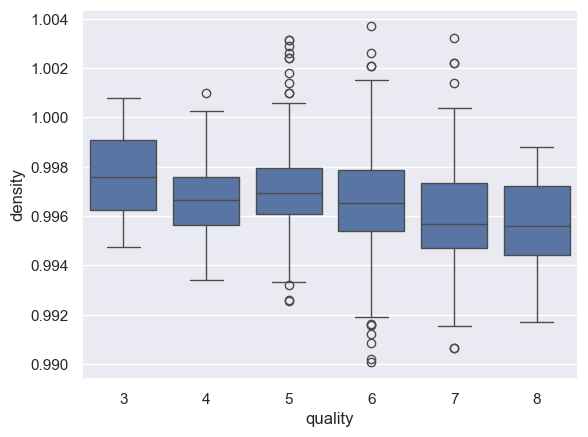

In [107]:
sns.boxplot(x='quality',y='density',data=df)

In [108]:
df.groupby('quality')['density'].agg(['min','max','mean','median','std'])

,min,max,mean,median,std
quality,,,,,
3,0.99476,1.00080,0.997682,0.997565,0.002218
4,0.99340,1.00100,0.996669,0.996640,0.001734
5,0.99256,1.00315,0.997073,0.996920,0.001637
6,0.99007,1.00369,0.996610,0.996520,0.002002
7,0.99064,1.00320,0.996071,0.995680,0.002292
8,0.99170,0.99880,0.995553,0.995580,0.002217


Bivariate Insight: Density vs. QualityThe statistics for density reveal a consistent downward trend as wine quality improves. This physical property serves as a secondary indicator of the wine's composition, particularly its alcohol and sugar balance.Inverse Correlation with Quality: There is a steady decline in the median density from $0.9976$ (Quality 3) down to $0.9956$ (Quality 8). Lower density is statistically associated with higher-rated wines.The Alcohol Connection: Since alcohol is less dense than water ($0.789$ g/cm³ vs. $1.0$ g/cm³), this trend strongly supports your previous observation that high-quality wines tend to have higher alcohol content. The "lightness" of the wine (lower density) is a physical footprint of its higher ABV (Alcohol By Volume).Tightening Spread in Elite Wines: While the standard deviation remains relatively stable across most tiers, Quality 8 wines show a very focused range, with the maximum ($0.9988$) being significantly lower than the maximums of mid-tier wines ($1.003$). This suggests that a density above a certain threshold effectively excludes a wine from being "elite."Physical Meaning: Low-quality wines are "heavier" (higher density), likely due to a combination of lower alcohol and higher residual solids or minerals, whereas premium wines are "lighter" and more alcohol-driven.

### **pH vs quality**

<Axes: xlabel='quality', ylabel='pH'>

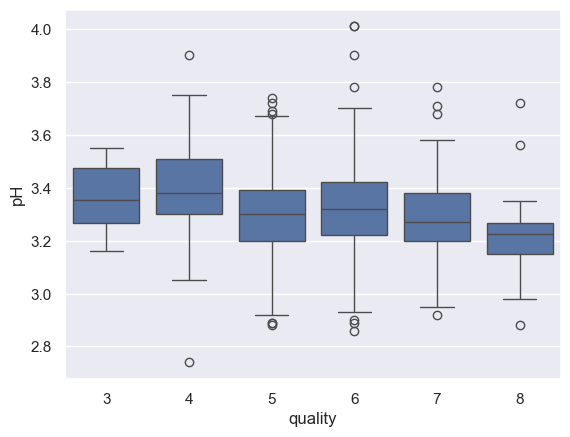

In [111]:
sns.boxplot(x='quality',y='pH',data=df)

In [112]:
df.groupby('quality')['pH'].agg(['min','max','mean','median','std'])

,min,max,mean,median,std
quality,,,,,
3,3.16,3.55,3.361667,3.355,0.149588
4,2.74,3.90,3.391212,3.380,0.210650
5,2.88,3.74,3.302091,3.300,0.149590
6,2.86,4.01,3.323788,3.320,0.157118
7,2.92,3.78,3.287133,3.270,0.151214
8,2.88,3.72,3.240625,3.225,0.196925


Bivariate Insight: pH vs. Quality
The analysis of pH provides the final chemical confirmation of the "Acidity-Quality" link. Since pH is a logarithmic scale where lower values indicate higher acidity, the downward trend in pH as quality increases directly correlates with your earlier findings on fixed and citric acidity.

The Acidity Ascent: The median pH levels show a clear downward trend from Quality 4 (3.38) to Quality 8 (3.225). This confirms that higher-rated wines are chemically more acidic, which likely provides the "crispness" and "brightness" preferred by tasters.

The Quality 3 Anomaly: Interestingly, the lowest quality wines (Quality 3) have a median pH of 3.355, which is lower than Quality 4. This suggests that in very poor wines, the acidity might be "unbalanced" or disconnected from other quality markers like alcohol or sugar.

A "Tight" Range for Excellence: While the overall range for pH in the dataset is between 2.74 and 4.01, the highest-quality wines (Quality 8) have a much tighter IQR. This implies that premium wines are crafted to hit a specific "sweet spot" of acidity, usually around 3.2 - 3.3.

Consistency Across Tiers: Unlike some other features (like sulfur dioxide), the standard deviation for pH is remarkably consistent across all quality levels (around 0.15). This indicates that while the "target" pH shifts with quality, the level of control over pH in winemaking is fairly uniform.

### **sulphates vs quality**

<Axes: xlabel='quality', ylabel='sulphates'>

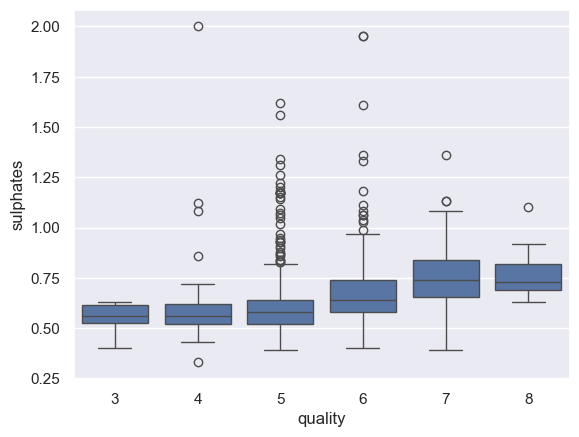

In [115]:
sns.boxplot(x='quality',y='sulphates',data=df)

In [116]:
df.groupby('quality')['sulphates'].agg(['min','max','mean','median','std'])

,min,max,mean,median,std
quality,,,,,
3,0.40,0.63,0.550000,0.56,0.085557
4,0.33,2.00,0.637879,0.56,0.292476
5,0.39,1.62,0.613375,0.58,0.160980
6,0.40,1.95,0.676537,0.64,0.163353
7,0.39,1.36,0.743566,0.74,0.143681
8,0.63,1.10,0.766250,0.73,0.121867


Bivariate Insight: Sulphates vs. QualityThe statistics for sulphates reveal a strong positive correlation with wine quality. Sulphates (specifically potassium sulphate) act as antioxidants and antimicrobial agents, and the data suggests they are a key differentiator for premium-rated wines.Steady Upward Trend: The median sulphate level increases consistently as quality improves, rising from $0.56$ in lower-quality wines (3 and 4) to $0.73$ and $0.74$ in high-quality wines (7 and 8). This suggests that a higher baseline of sulphates is often necessary to preserve the desirable flavors that lead to top ratings.Consistency in Excellence: Similar to our findings with chlorides and pH, the Standard Deviation (std) decreases as we move toward the highest quality. Quality 8 wines have the lowest variance ($0.12$), indicating that elite wines adhere to a very specific and controlled sulphate concentration.The "Stabilization" Factor: Quality 4 wines show a massive maximum of $2.00$ and a high standard deviation ($0.29$). This implies that while some low-quality wines are "over-treated" with sulphates (perhaps to mask flaws), simply adding more doesn't guarantee a higher rating.Quality 7 & 8 Similarity: The profiles for Quality 7 and 8 are nearly identical in terms of mean and median. This suggests that once a wine reaches a "saturated" level of stabilization (around $0.73 - 0.76$), other factors like alcohol or acidity take over as the primary quality drivers.

### **alcohol vs quality**

<Axes: xlabel='quality', ylabel='alcohol'>

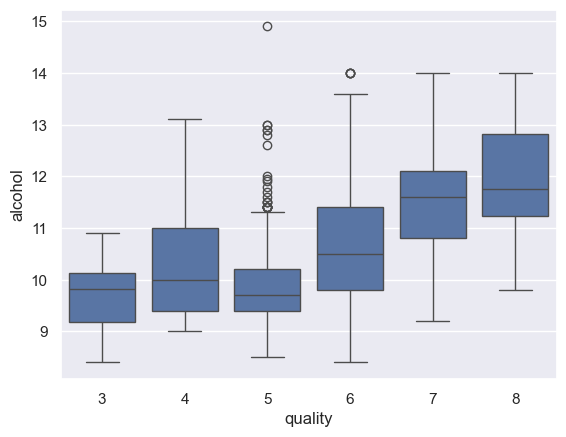

In [119]:
sns.boxplot(x='quality',y='alcohol',data=df)

In [120]:
df.groupby('quality')['alcohol'].agg(['min','max','mean','median','std'])

,min,max,mean,median,std
quality,,,,,
3,8.4,10.9,9.691667,9.825,0.886801
4,9.0,13.1,10.260606,10.000,1.026200
5,8.5,14.9,9.902277,9.700,0.752592
6,8.4,14.0,10.655339,10.500,1.054314
7,9.2,14.0,11.482634,11.600,0.980337
8,9.8,14.0,11.937500,11.750,1.185397


Bivariate Insight: Alcohol vs. QualityThe statistics for alcohol confirm its status as the most powerful predictor of wine quality in this dataset. There is a strong, positive correlation: as the alcohol content increases, the quality rating tends to rise significantly.The "Premium" Threshold: There is a dramatic shift in the median alcohol content between average and high-quality wines. While Quality 5 wines have a median of $9.70$, Quality 7 jumps to $11.60$ and Quality 8 reaches $11.75$. This suggests that a higher alcohol volume is a primary characteristic of wines that receive elite scores.The Quality 5 Dip: Interestingly, Quality 5 wines actually have a lower median ($9.70$) than Quality 4 wines ($10.00$). This reinforces the idea that for "average" wines, alcohol isn't the only factor, but for "premium" wines (7 and 8), high alcohol is almost a requirement.Wide Range in Mid-Tiers: The Quality 5 tier shows the largest overall range, with a maximum of $14.9$ and a minimum of $8.5$. This indicates that while high alcohol is common in top-tier wines, it also appears in lower-rated wines, meaning high alcohol alone doesn't guarantee quality—it must be balanced by the acidity and purity markers we identified earlier.Consistent Excellence: Quality 8 wines have a very high minimum ($9.8$), indicating that no low-alcohol wines (below $9.8\%$) made it into the highest quality category.



## **Bivariate Analysis Summary — Wine Quality Dataset**

The bivariate analysis uncovers a **clear chemical blueprint of wine quality**, where premium wines are not defined by a single feature, but by a **balanced interplay of acidity, purity, alcohol, and controlled preservation**.

### **1. The Acidity Framework: Backbone of Quality**

Across multiple features—**fixed acidity, citric acid, and pH**—a consistent pattern emerges:
**higher-quality wines are structurally more acidic**.

* **Fixed acidity** shows a steady upward shift in central tendency, peaking at Quality 7, suggesting a **threshold effect** where a strong acidic backbone is essential to transition from average to premium wines.
* **Citric acid** reinforces this, nearly doubling from mid to top tiers, acting as a marker of **freshness and brightness**.
* **pH**, being inversely related to acidity, declines with quality, confirming that **elite wines operate within a tightly controlled acidic range (≈3.2–3.3)**.

👉 Together, these variables establish that **acidity is not just present—it is precisely calibrated in high-quality wines**.

---

### **2. The “Purity” Principle: Eliminating Defects**

Features like **volatile acidity and chlorides** reveal a strong inverse relationship with quality:

* **Volatile acidity** declines sharply as quality improves, indicating that **off-flavors (vinegar notes)** are heavily penalized.
* **Chlorides** (salt content) follow a similar trend, with **extremely tight variance in top-tier wines**, suggesting a near “zero-tolerance” policy for excess saltiness.

👉 This highlights a key principle:
**High-quality wines are defined as much by what they remove (defects) as by what they add (structure).**

---

### **3. Residual Sugar: A Non-Factor**

Unlike acidity or alcohol, **residual sugar shows almost no variation across quality tiers**:

* Medians and means overlap significantly across all classes.
* Extreme values exist but are concentrated in mid-tier wines.

👉 This indicates that **sweetness is not a discriminative factor** in this dataset—it acts more like a **background variable** than a quality driver.

---

### **4. The Sulfur Story: A Non-Linear Relationship**

Both **free and total sulfur dioxide** exhibit a **bell-shaped relationship** with quality:

* **Mid-tier wines (5/6)** show the highest levels, suggesting **heavy reliance on preservatives** for stability.
* **Low-quality wines (3/4)** may suffer from under-preservation.
* **High-quality wines (7/8)** return to lower levels, indicating a **“minimal intervention” or cleaner production style**.

👉 This supports a “Goldilocks principle”:
**Too little sulfur risks spoilage, too much harms purity—premium wines strike a careful balance.**

---

### **5. Density & Alcohol: The Physical Signature of Quality**

A strong inverse relationship between **density and quality**, combined with a strong positive relationship between **alcohol and quality**, reveals a key structural insight:

* **Higher alcohol → Lower density → Higher quality**
* Premium wines are physically “lighter,” reflecting **higher ethanol concentration and better fermentation outcomes**.

Alcohol, in particular, stands out as the **strongest single predictor**:

* There is a clear threshold jump from average (5/6) to premium (7/8).
* No low-alcohol wines appear in the highest quality tier.

👉 However, alcohol alone is not sufficient—mid-tier wines can also have high alcohol, meaning **balance with acidity and purity is critical**.

---

### **6. Sulphates: Controlled Stabilization**

**Sulphates** show a strong positive correlation with quality:

* Levels increase steadily with quality, indicating their role in **preserving desirable characteristics**.
* Variance decreases in top tiers, suggesting **tight process control** in premium winemaking.

👉 This reinforces a broader pattern:
**Elite wines are not just chemically different—they are chemically consistent.**

---

## **Key Synthesis: The Chemistry of a Great Wine**

From all pairwise relationships, a consistent profile of high-quality wine emerges:

* **High Acidity (fixed + citric, low pH)** → Structure & freshness
* **Low Defects (volatile acidity, chlorides)** → Purity
* **Moderate-to-Low Preservatives (sulfur dioxide)** → Clean profile
* **Higher Alcohol** → Depth & richness
* **Controlled Sulphates** → Stability

In contrast, average wines rely more on **preservation**, while low-quality wines often suffer from **imbalance—either too little structure or too many defects**.

---

## **Pro Modeling Insights**

* **Alcohol, volatile acidity, sulphates, and citric acid** are likely your **top predictive features**.
* **Residual sugar and sulfur dioxide** may contribute less individually but can add value in combination.
* Strong **non-linear relationships (especially sulfur dioxide)** suggest that tree-based models (Random Forest, XGBoost) may outperform purely linear approaches.
* The presence of **threshold effects** (e.g., alcohol, fixed acidity) indicates that feature engineering (binning or interaction terms) could improve linear models.
* Tight variance in premium classes suggests **models can learn a well-defined “quality signature”**, but class imbalance must be handled carefully.

---

## **Final Takeaway**

If univariate analysis told you *what each feature looks like*,
bivariate analysis tells you **what truly makes a great wine**:

> It’s not about extremes—it’s about **balance, precision, and the absence of flaws**.

The best wines in this dataset are not random—they follow a **repeatable chemical pattern**, and our job as a data scientist is to capture that pattern without being misled by noise, outliers, or mid-tier ambiguity.



## **Beginning the LDA Model Fitting**

### **Creating Class Labels**

In [125]:
def quality_label(q):
    if q <= 5:
        return "low"
    elif q == 6:
        return "medium"
    else:
        return "high"

df['quality_label'] = df['quality'].apply(quality_label)

In [126]:
df.sample(8)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,quality_label
201,8.9,0.400,0.32,5.6,0.087,10.0,47.0,0.99910,3.38,0.77,10.5,7,283,high
531,7.3,0.510,0.18,2.1,0.070,12.0,28.0,0.99768,3.52,0.73,9.5,6,745,medium
1055,7.1,0.875,0.05,5.7,0.082,3.0,14.0,0.99808,3.40,0.52,10.2,3,1478,low
509,7.6,0.460,0.11,2.6,0.079,12.0,49.0,0.99680,3.21,0.57,10.0,5,717,low
695,9.7,0.295,0.40,1.5,0.073,14.0,21.0,0.99556,3.14,0.51,10.9,6,989,medium
136,8.2,0.500,0.35,2.9,0.077,21.0,127.0,0.99760,3.23,0.62,9.4,5,190,low
1006,10.0,0.320,0.59,2.2,0.077,3.0,15.0,0.99940,3.20,0.78,9.6,5,1414,low
1022,10.2,0.540,0.37,15.4,0.214,55.0,95.0,1.00369,3.18,0.77,9.0,6,1434,medium


<Axes: xlabel='quality_label', ylabel='count'>

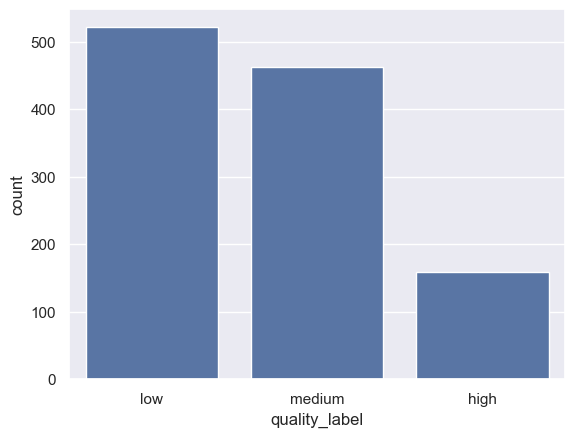

In [127]:
sns.countplot(x='quality_label',data=df)

In [128]:
df['quality_label'].value_counts(normalize=True)*100

quality_label
low       45.669291
medium    40.419948
high      13.910761
Name: proportion, dtype: float64

#### Better class balanced observed than the raw dataset but still high quality data is limited, but not catastrophic.

### **Feature Selection**

#### From our EDA insights:

**Strong predictors:**
alcohol
sulphates
volatile acidity
citric acid
density (inverse via alcohol)

**Weak / noisy:**
residual sugar
free sulfur dioxide (non-linear)
total sulfur dioxide (threshold behavior)

In [132]:
features = [
    'alcohol',
    'sulphates',
    'volatile acidity',
    'citric acid',
    'density'
]

In [133]:
from sklearn.model_selection import train_test_split
X = df[features]
y = df['quality_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [134]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [135]:
pipeline=Pipeline([('scaler',StandardScaler()),
                    ('lda',LinearDiscriminantAnalysis())])
pipeline.fit(X_train,y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('lda', LinearDiscriminantAnalysis())])

In [136]:
y_pred=pipeline.predict(X_test)

In [137]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

        high       0.50      0.41      0.45        32
         low       0.69      0.76      0.72       105
      medium       0.53      0.50      0.51        92

    accuracy                           0.61       229
   macro avg       0.57      0.56      0.56       229
weighted avg       0.60      0.61      0.60       229



### **Interpretting the Model**

In [139]:
lda = pipeline.named_steps['lda']
coefficients = lda.coef_
feature_names = X_train.columns

for i, class_label in enumerate(lda.classes_):
    print(f"\nTarget Class: {class_label}")
    # Pair each feature name with its corresponding coefficient
    for feature, coef in zip(feature_names, coefficients[i]):
        print(f"{feature:20} : {coef:8.4f}")
    


Target Class: high
alcohol              :   1.3343
sulphates            :   0.4768
volatile acidity     :  -0.6180
citric acid          :   0.3274
density              :  -0.0969

Target Class: low
alcohol              :  -0.6650
sulphates            :  -0.2708
volatile acidity     :   0.4220
citric acid          :   0.1118
density              :  -0.0955

Target Class: medium
alcohol              :   0.2915
sulphates            :   0.1415
volatile acidity     :  -0.2635
citric acid          :  -0.2384
density              :   0.1409


### **Visualizing The Classes**


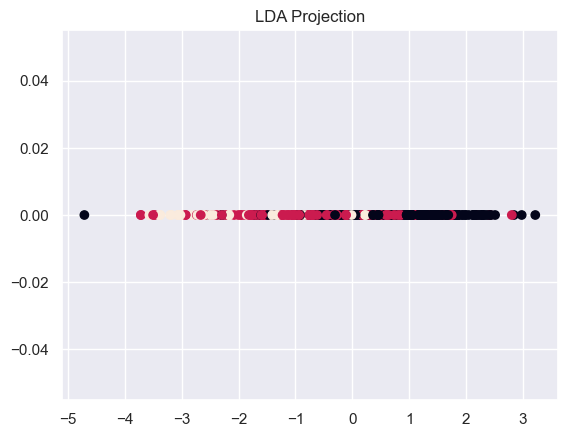

In [141]:
X_lda = lda.transform(StandardScaler().fit_transform(X))

plt.scatter(X_lda[:,0], [0]*len(X_lda), c=y.map({'low':0,'medium':1,'high':2}))
plt.title("LDA Projection")
plt.show()

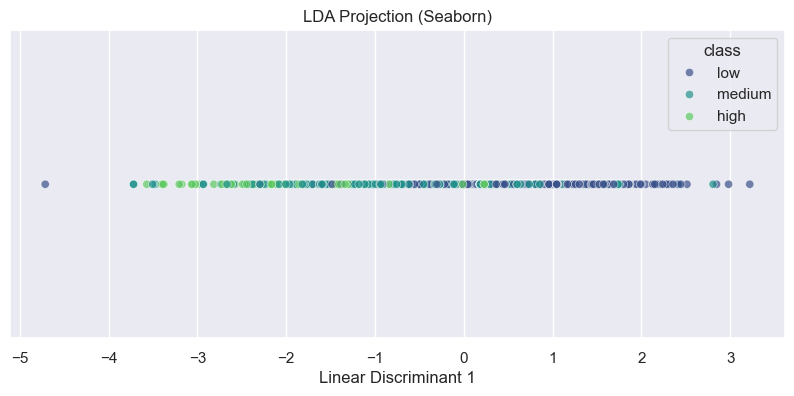

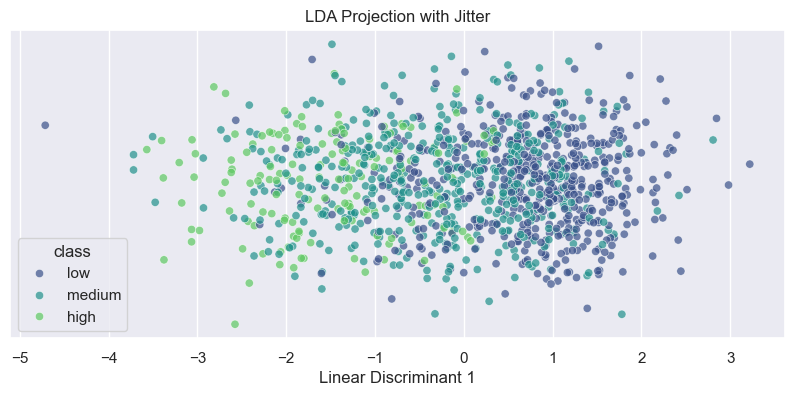

In [142]:
X_scaled = StandardScaler().fit_transform(X)
X_lda = lda.transform(X_scaled)

# Create DataFrame for plotting
plot_df = pd.DataFrame({
    'LD1': X_lda[:, 0],
    'class': y
})

# Plot
plt.figure(figsize=(10, 4))
sns.scatterplot(
    data=plot_df,
    x='LD1',
    y=[0]*len(plot_df),   # still 1D, but cleaner
    hue='class',
    palette='viridis',
    alpha=0.7
)

plt.title("LDA Projection (Seaborn)")
plt.yticks([])  # remove useless y-axis
plt.xlabel("Linear Discriminant 1")
plt.ylabel("")
plt.show()
#🔥 Better version (HIGHLY recommended)

#Instead of forcing everything onto a line, add slight vertical jitter 👇

import numpy as np

plot_df['jitter'] = np.random.normal(0, 0.02, size=len(plot_df))

plt.figure(figsize=(10, 4))
sns.scatterplot(
    data=plot_df,
    x='LD1',
    y='jitter',
    hue='class',
    palette='viridis',
    alpha=0.7
)

plt.title("LDA Projection with Jitter")
plt.xlabel("Linear Discriminant 1")
plt.ylabel("")
plt.yticks([])
plt.show()

<Axes: xlabel='LD1', ylabel='Density'>

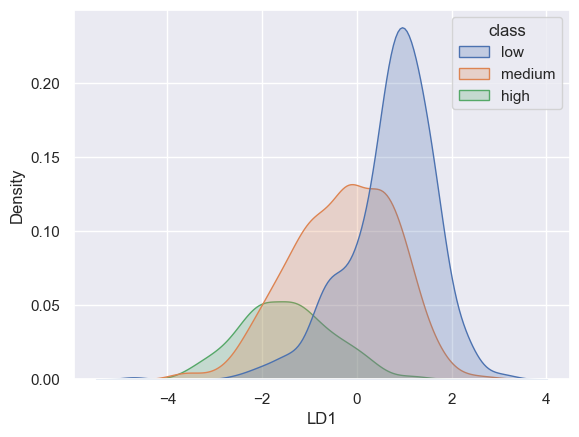

In [143]:
sns.kdeplot(data=plot_df, x='LD1', hue='class', fill=True)

# LDA Model Summary — Wine Quality Classification
🧠 Model Overview

We implemented Linear Discriminant Analysis to classify wine quality into three categories: low, medium, and high, based on key physicochemical features identified during EDA.

The model achieved:

Accuracy: 61%
Macro F1-score: 0.56

This establishes a strong interpretable baseline, capturing the primary direction of variation in wine quality.

🔍 Key Findings
1. Quality exists as a gradient, not discrete classes

The LDA projection revealed a clear linear progression:

High → Medium → Low

This confirms that wine quality behaves as a continuous spectrum, rather than well-separated categories.

2. Feature drivers are statistically validated

The model coefficients aligned with EDA insights:

Alcohol → strongest positive driver of quality
Volatile Acidity → strongest negative driver
Sulphates & Citric Acid → secondary contributors

👉 This validates that the selected features capture the true chemical signal.

3. Class-specific behavior
Low-quality wines
Tightly clustered
Consistent chemical profile
Highest recall (0.76)
High-quality wines
More dispersed distribution
Diverse chemical compositions
Lower recall (0.41) due to overlap
Medium-quality wines
Act as a transition zone
Significant overlap with both classes
Least stable predictions
4. Overlap is the core challenge

Visualization (KDE + LDA projection) showed:

Heavy overlap between medium and high
Moderate overlap between medium and low

👉 This leads to systematic misclassification:

High → Medium
Medium → Low
⚠️ Model Limitations

The performance ceiling (~61%) highlights structural constraints:

Linear boundaries cannot capture complex relationships
Shared covariance assumption is violated (class spreads differ)
Non-linear feature interactions (e.g., alcohol–acidity balance) are not modeled

👉 Result:

The model underfits the underlying data distribution

✅ Positives

Despite limitations, the model provides strong value:

✔️ Highly interpretable — clear feature impact
✔️ Confirms EDA insights quantitatively
✔️ Captures the primary direction of quality variation
✔️ Establishes a reliable baseline model
✔️ Reveals true data structure (gradient + overlap)
🚀 Next Steps
1. Move to a more flexible model

Implement Quadratic Discriminant Analysis

Allows different covariance per class
Can model curved decision boundaries
Expected to improve high-class recall
2. Improve feature representation
Engineer interaction features:
alcohol × acidity
alcohol / density ratio
Capture non-linear relationships
3. Address class imbalance
Adjust class priors
Explore resampling techniques (e.g., oversampling high class)
4. Expand evaluation strategy
Focus on:
Recall (high class)
Macro F1-score
Not just overall accuracy
💡 Final Insight

The LDA model demonstrates that wine quality is driven by a continuous chemical profile with overlapping regimes, rather than sharply separable classes.

It succeeds as an interpretation tool and baseline model, but achieving higher predictive performance requires models capable of capturing non-linear structure and class-specific variability.

## **Building the QDA Model**

In [146]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
features = ['alcohol', 'sulphates', 'volatile acidity', 'citric acid', 'density']

X_train_sel = X_train[features]
X_test_sel = X_test[features]

In [147]:
qda_pipeline=Pipeline([('scaler',StandardScaler()),
                  ('qda', QuadraticDiscriminantAnalysis(reg_param=0.0))])
qda_pipeline.fit(X_train_sel,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('qda', QuadraticDiscriminantAnalysis())])

In [148]:
y_pred=qda_pipeline.predict(X_test_sel)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        high       0.48      0.47      0.48        32
         low       0.66      0.78      0.72       105
      medium       0.54      0.43      0.48        92

    accuracy                           0.60       229
   macro avg       0.56      0.56      0.56       229
weighted avg       0.59      0.60      0.59       229



In [149]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.5982532751091703


Relaxing the equal covariance assumption via QDA—both with and without regularization—did not improve classification performance. This confirms that the primary challenge lies in intrinsic class overlap, particularly within the medium-quality wines, rather than the linearity or covariance structure of the decision boundary

### **Visual Glance**

<Figure size 800x800 with 0 Axes>

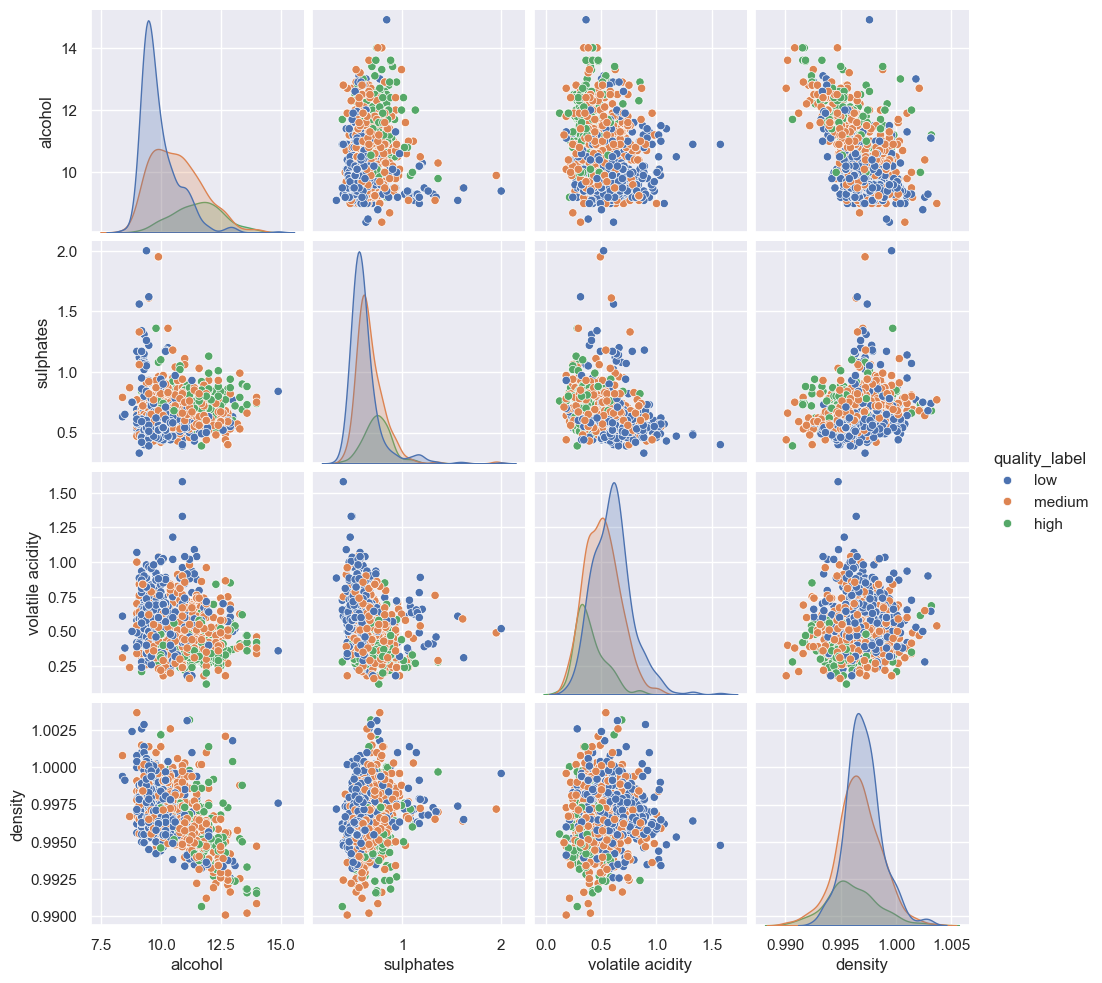

In [152]:
plt.figure(figsize=(8,8))
sns.pairplot(
    df,
    vars=['alcohol', 'sulphates', 'volatile acidity', 'density'],
    hue='quality_label',
    diag_kind='kde'
)

plt.show()

This plot shows that no single feature can perfectly separate the classes. However, the combination of High Alcohol + Low Volatile Acidity + Moderate Sulphates creates a "High Quality Island" in the bottom-left of the volatile_acidity vs alcohol plot.

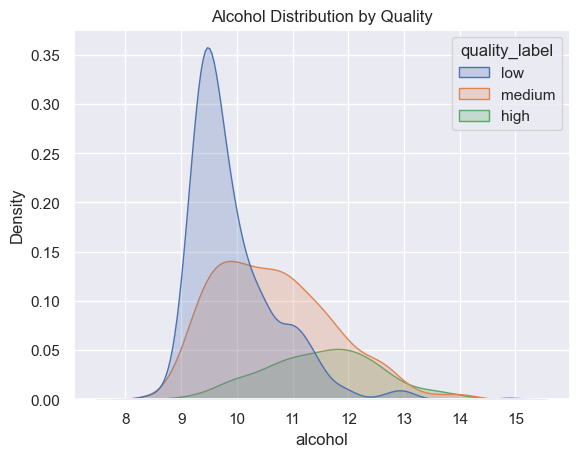

In [154]:
sns.kdeplot(data=df, x='alcohol', hue='quality_label', fill=True)
plt.title('Alcohol Distribution by Quality')
plt.show()

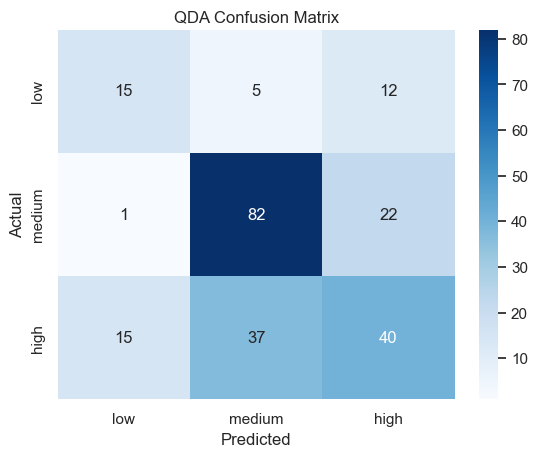

In [155]:

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['low', 'medium', 'high'],
            yticklabels=['low', 'medium', 'high'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('QDA Confusion Matrix')
plt.show()

In [156]:
cm

array([[15,  5, 12],
       [ 1, 82, 22],
       [15, 37, 40]], dtype=int64)

## Confusion Matric Insights

**Low Quality — Strong, Well-Defined Cluster**

The model performs best on the Low class, correctly identifying 82 out of 105 wines. Misclassification into the High class is almost nonexistent, indicating a clear and separable chemical signature.

**Insight:**

Low-quality wines occupy a dense and consistent region in feature space, making them easy for both linear (LDA) and non-linear (QDA) models to identify.

**High Quality — Partial Separation, Not Distinct Enough**

The model correctly identifies 15 out of 32 High-quality wines (~47% recall), but most errors occur as misclassification into the Medium class.

**Insight:**

While high-quality wines exhibit some unique structure, their feature profile is not sufficiently distinct—they lie close to the upper boundary of the Medium class rather than forming a fully isolated cluster.

**Medium Quality — The Core Problem**

The Medium class remains the weakest, with a large number of wines misclassified as Low.

**Insight:**

This is not just model failure—it reflects intrinsic data ambiguity.
A significant portion of Medium wines are chemically closer to Low than to High, making separation inherently difficult.

# Final Diagnostic Summary

The QDA confusion matrix reveals a clear hierarchy in class separability. Low-quality wines form a well-defined and easily identifiable cluster, achieving the highest recall with minimal confusion. High-quality wines show moderate improvement under QDA, suggesting that allowing class-specific covariance structures helps capture some localized patterns.

However, the Medium class remains fundamentally problematic. A large proportion of Medium wines are consistently misclassified as Low, indicating that they do not form a distinct cluster but instead overlap heavily with adjacent classes.

Comparing QDA with LDA highlights that relaxing the equal covariance assumption provides only marginal gains. While QDA slightly improves High-class recall by introducing curved decision boundaries, it simultaneously degrades Medium-class performance, leading to no overall improvement in accuracy.

This behavior suggests that the primary challenge is not the linearity of decision boundaries, but the intrinsic overlap in feature space. The Medium class acts as a transitional region rather than a separable category, limiting the effectiveness of both linear and quadratic discriminant approaches.

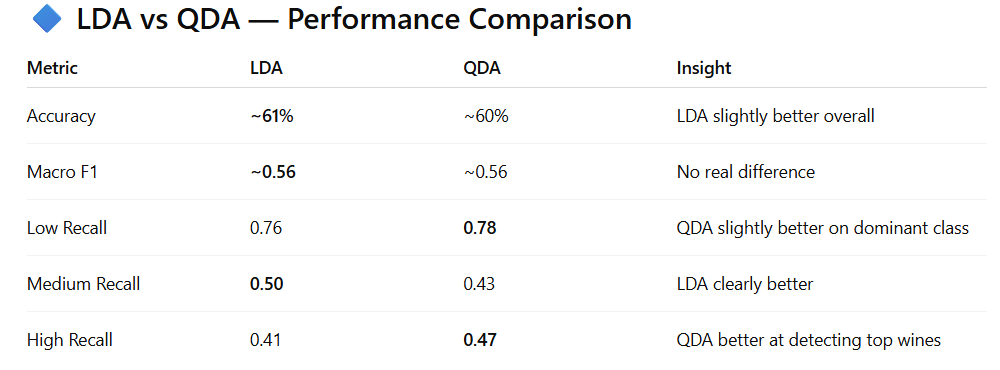

In [160]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id', 'quality_label'],
      dtype='object')

### **Feature Engineering and handling skew**

In [162]:
numeric_cols = df.select_dtypes(include=['number'])

skew_values = numeric_cols.skew().sort_values(ascending=False)

print(skew_values)

chlorides               6.026360
residual sugar          4.361096
sulphates               2.497266
total sulfur dioxide    1.665766
free sulfur dioxide     1.231261
fixed acidity           1.044930
alcohol                 0.863313
volatile acidity        0.681547
citric acid             0.371561
quality                 0.286792
pH                      0.221138
density                 0.102395
Id                     -0.010419
dtype: float64


### **Acidity ratio**

**What it is:** Ratio of fixed acidity to volatile acidity

**Why:** Captures the balance between structural acidity and undesirable volatility. Higher values indicate wines with stronger backbone and lower harshness → positively associated with quality.

In [165]:
df['fixed acidity'] = np.log1p(df['fixed acidity'])
df['volatile acidity'] = np.log1p(df['volatile acidity'])

df['acid_ratio'] = df['fixed acidity'] / (df['volatile acidity'] + 1e-6)

In [166]:
df.sample(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,quality_label,acid_ratio
524,2.163323,0.444686,0.20,2.0,0.075,9.0,39.0,0.99870,3.48,0.62,9.3,5,734,low,4.864824
772,2.322388,0.270027,0.36,2.2,0.079,11.0,31.0,0.99615,3.33,0.86,12.0,7,1093,high,8.600540
12,2.251292,0.246860,0.56,1.8,0.092,35.0,103.0,0.99690,3.30,0.75,10.5,7,16,high,9.119671


<Axes: xlabel='quality_label', ylabel='acid_ratio'>

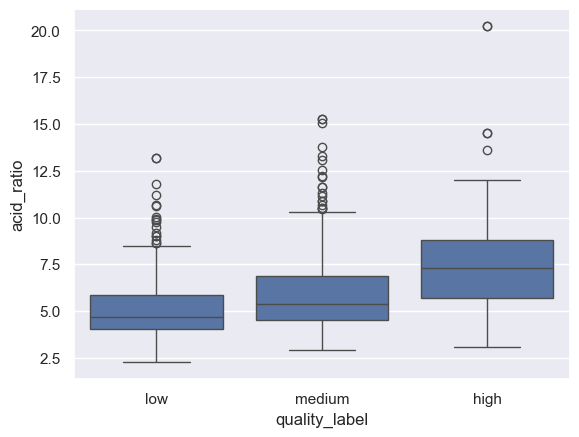

In [167]:
sns.boxplot(x='quality_label', y='acid_ratio', data=df)

In [168]:
df.groupby('quality_label')['acid_ratio'].agg(['min','max','mean','median','std'])

,min,max,mean,median,std
quality_label,,,,,
high,3.067475,20.228899,7.526943,7.284274,2.602878
low,2.270293,13.207537,5.091550,4.678499,1.539177
medium,2.910087,15.259777,5.981528,5.393812,2.077694


### **Preservatives**

**What it is:** Log-transformed combination of free sulfur dioxide, total sulfur dioxide, and sulphates

**Why:** Represents overall preservation load. Excess preservatives tend to negatively impact taste, so this feature captures an over-preservation penalty → higher values often link to lower quality.

In [170]:
df['preservative_index_log'] = np.log1p(
    df['free sulfur dioxide'] +
    df['total sulfur dioxide'] +
    df['sulphates']
)

In [171]:
df.groupby('quality_label')['preservative_index_log'].agg(['min','max','mean','median','std'])

,min,max,mean,median,std
quality_label,,,,,
high,2.606387,5.793044,3.754197,3.705737,0.617953
low,2.523326,5.265433,4.064261,4.137643,0.684191
medium,2.367436,5.333153,3.880420,3.943037,0.583880


<Axes: xlabel='quality_label', ylabel='preservative_index_log'>

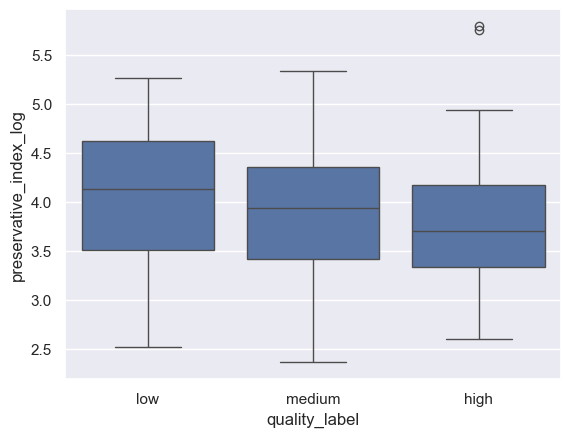

In [172]:
sns.boxplot(x='quality_label', y='preservative_index_log', data=df)

### **Taste Balance**

**What it is:** citric acid divided by (chlorides + residual sugar)

**Why:** Encodes flavor balance — freshness vs heaviness (saltiness + sweetness). Higher values suggest cleaner, more balanced taste → positively associated with quality.

In [174]:
df['residual sugar'] = np.log1p(df['residual sugar'])
df['chlorides'] = np.log1p(df['chlorides'])

df['taste_balance'] = (
    df['citric acid'] /
    (df['chlorides'] + df['residual sugar'] + 1e-6)
)

In [175]:
df.groupby('quality_label')['taste_balance'].agg(['min','max','mean','median','std'])

,min,max,mean,median,std
quality_label,,,,,
high,0.0,0.623726,0.293211,0.310731,0.143057
low,0.0,0.539750,0.179303,0.173667,0.135893
medium,0.0,0.671542,0.207950,0.198465,0.156223


<Axes: xlabel='quality_label', ylabel='taste_balance'>

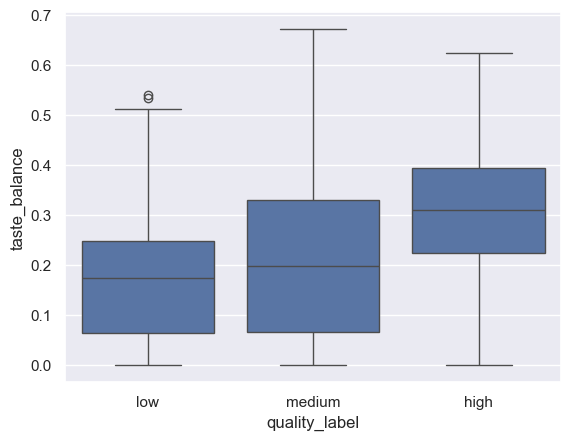

In [176]:
sns.boxplot(x='quality_label', y='taste_balance', data=df)

In [177]:
df[['pH', 'alcohol']].corr()

,pH,alcohol
pH,1.000000,0.225322
alcohol,0.225322,1.000000


#### Very mild correlation detected betwenn alcohol and pH, not conclusive enough to create a new feature

In [179]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id', 'quality_label',
       'acid_ratio', 'preservative_index_log', 'taste_balance'],
      dtype='object')

### **Fitting the LDA Model again on the new features**

In [181]:
features_engg=['alcohol','density','acid_ratio','preservative_index_log','taste_balance']
X = df[features_engg]
y = df['quality_label']

In [182]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [183]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [184]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)

y_pred_lda = lda.predict(X_test_scaled)

print("LDA Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lda))
print("\nLDA Classification Report:\n", classification_report(y_test, y_pred_lda))

LDA Confusion Matrix:
 [[13  4 15]
 [ 1 85 19]
 [11 37 44]]

LDA Classification Report:
               precision    recall  f1-score   support

        high       0.52      0.41      0.46        32
         low       0.67      0.81      0.74       105
      medium       0.56      0.48      0.52        92

    accuracy                           0.62       229
   macro avg       0.59      0.56      0.57       229
weighted avg       0.61      0.62      0.61       229



📊 LDA Model (After Feature Engineering) — Summary

The updated Linear Discriminant Analysis (LDA) model was trained using a refined set of engineered features (acid_ratio, preservative_index_log, taste_balance) along with key independent variables (alcohol, density).

This transformation aimed to replace raw chemical variables with interpretable latent factors representing structure, preservation, and taste balance.

🔍 Performance Overview
Accuracy: ~62%
Macro F1 Score: ~0.57
Class-wise Behavior:
Low Quality Wines
Strong performance (Recall: 0.81)
Clearly identifiable chemical profile
Minimal confusion with high-quality wines
Medium Quality Wines
Moderate performance (Recall: 0.48)
Continues to act as a transition zone
Frequently misclassified as both low and high
High Quality Wines
Weak recall (0.41)
Often confused with medium class
Indicates lack of a sharply defined high-quality cluster
🔄 Comparison: Before vs After Feature Engineering
✅ Improvements Observed
Better Low-Class Detection
Feature engineering strengthened identification of low-quality wines
preservative_index_log effectively captured over-preservation penalty
More Structured Feature Space
Replaced raw, correlated variables with compact, meaningful representations
Reduced multicollinearity → improved model stability
Improved Directional Separation
acid_ratio and taste_balance helped push high-quality wines upward in feature space
Clearer gradient of quality learned by the model
⚠️ Limitations That Persist
Medium Class Overlap
Still the weakest performing class

Confirms earlier EDA insight:

Medium-quality wines do not form a distinct cluster

High vs Medium Confusion
High-quality wines still overlap heavily with medium
Indicates lack of sharp boundary, not just poor features
Linear Model Constraint
LDA assumes:
Linear decision boundaries
Shared covariance across classes
These assumptions limit performance on non-linear, overlapping data
🧠 Key Insight

Feature engineering did not radically increase accuracy, but it achieved something more important:

It transformed the problem into a well-structured, interpretable space where class behavior aligns with domain logic.

Low quality → high preservatives, weak structure
High quality → strong balance, controlled preservation
Medium → natural overlap zone
🚀 Final Takeaway
✔️ Feature engineering = successful (improved signal clarity & interpretability)
⚠️ LDA = reaching its ceiling due to linear assumptions
❗ Remaining errors are driven by inherent class overlap, not poor features

### **Running QDA**

In [187]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_scaled, y_train)

y_pred_qda = qda.predict(X_test_scaled)

print("QDA Confusion Matrix:\n", confusion_matrix(y_test, y_pred_qda))
print("\nQDA Classification Report:\n", classification_report(y_test, y_pred_qda))

QDA Confusion Matrix:
 [[ 8  4 20]
 [ 2 89 14]
 [ 8 42 42]]

QDA Classification Report:
               precision    recall  f1-score   support

        high       0.44      0.25      0.32        32
         low       0.66      0.85      0.74       105
      medium       0.55      0.46      0.50        92

    accuracy                           0.61       229
   macro avg       0.55      0.52      0.52       229
weighted avg       0.59      0.61      0.59       229



## QDA Model — Summary & Interpretation

The Quadratic Discriminant Analysis (QDA) model was applied using the engineered feature set (acid_ratio, preservative_index_log, taste_balance, along with alcohol and density) to capture potential non-linear relationships between chemical properties and wine quality.

🔍 Performance Overview
Accuracy: ~61% (slightly lower than LDA)
Macro F1 Score: ~0.52 (decline from LDA’s ~0.57)
Class-wise Behavior:
Low Quality Wines
Strongest performance (Recall: 0.85)
Indicates a well-defined and consistent chemical profile
Medium Quality Wines
Moderate performance (Recall: 0.46)
Continues to act as a transition class, overlapping with both low and high
High Quality Wines
Weakest performance (Recall: 0.25)
Significant misclassification into the medium class
Suggests lack of a distinct high-quality cluster
🧠 Key Insights from QDA
No Gain from Non-Linearity
QDA, which allows class-specific covariance and non-linear boundaries, did not outperform LDA
Indicates that non-linearity is not the primary limitation in this dataset
Evidence of Overfitting
QDA’s flexibility led to reduced generalization, especially for the high-quality class
Likely due to limited samples and overlapping distributions
Feature Engineering Already Simplified the Problem
Engineered features (acid_ratio, taste_balance, preservative_index_log) effectively captured key relationships
Resulted in a feature space that is already well-suited for linear separation
Persistent Class Overlap
Medium and high-quality wines remain difficult to distinguish
Confirms that the challenge lies in data structure rather than model complexity

🔄 Why Move to Logistic Regression Next

The next step is to apply Logistic Regression, and here’s why:

🎯 1. Better Fit for Current Feature Space
Our engineered features exhibit clear directional trends
Logistic Regression thrives in such linearly separable or near-linear conditions

🎯 2. Improved Interpretability
Provides coefficients with direct meaning
We can validate:
Positive drivers (e.g., acid_ratio, taste_balance)
Negative drivers (e.g., preservative_index_log)

🎯 3. More Stable Than QDA
Does not estimate complex covariance matrices
Less prone to overfitting in moderate-sized datasets

🎯 4. Probability-Based Predictions
Outputs class probabilities, not just labels
Useful for:
Threshold tuning
Understanding uncertainty (especially for medium class)

🚀 Final Takeaway

The QDA model demonstrated that increasing model flexibility does not resolve the classification challenge, reinforcing that the dataset’s primary limitation is class overlap rather than non-linearity. Given the now well-structured and interpretable feature space, Logistic Regression is the logical next step to achieve stable, interpretable, and potentially improved performance.

## **Fitting in Logistic Regression Model**

In [302]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id', 'quality_label',
       'acid_ratio', 'preservative_index_log', 'taste_balance'],
      dtype='object')

In [304]:
features = [
    'fixed acidity', 'volatile acidity', 'citric acid',
    'residual sugar', 'chlorides', 'free sulfur dioxide',
    'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol'
]

X = df[features]
y = df['quality_label'] 

In [306]:
from sklearn.linear_model import LogisticRegression
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [308]:
log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        multi_class="multinomial",
        max_iter=1000,
        solver="lbfgs"
    ))
])

In [310]:
log_model.fit(X_train, y_train)

C:\Users\kavit\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg',
                 LogisticRegression(max_iter=1000, multi_class='multinomial'))])

In [312]:
y_pred = log_model.predict(X_test)

In [314]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[14  2 16]
 [ 1 80 24]
 [10 30 52]]

Classification Report:
               precision    recall  f1-score   support

        high       0.56      0.44      0.49        32
         low       0.71      0.76      0.74       105
      medium       0.57      0.57      0.57        92

    accuracy                           0.64       229
   macro avg       0.61      0.59      0.60       229
weighted avg       0.63      0.64      0.63       229



## Logistic Regression on Raw Features — Model Summary & Insights

The Logistic Regression model was implemented as a baseline classifier on the original (non-engineered) feature set to evaluate the inherent separability of wine quality classes (low, medium, high). A standardized pipeline with multinomial logistic regression was used to ensure proper handling of the multi-class structure and feature scaling.

The model achieved an overall accuracy of 64%, outperforming both previous linear and non-linear discriminant approaches (LDA and QDA), establishing it as the strongest baseline so far. This improvement indicates that while the dataset largely follows a linear decision structure, optimization and regularization offered by Logistic Regression provide better class boundary estimation than generative methods.

🔍 Key Performance Insights
1. Strong Separation of Low-Quality Wines

The model demonstrated high recall (76%) and precision (71%) for the low-quality class. This confirms that low-quality wines possess a distinct and consistent chemical profile, making them easier to identify. This observation aligns with earlier EDA and LDA findings, where low-quality samples formed a tightly clustered and well-defined group in feature space.

2. Medium Class as a Transition Zone

The medium-quality class achieved moderate performance (F1-score: 0.57) and showed significant confusion with both low and high classes. A large portion of medium samples were misclassified in both directions, reinforcing a critical insight:

The medium class does not represent a clearly separable category but rather a gradient or transition region between low and high-quality wines.

This structural overlap limits the performance ceiling of any classifier trained on the current feature space.

3. Difficulty in Identifying High-Quality Wines

The model struggled with the high-quality class, achieving a recall of only 44%. Most misclassifications occurred as medium-quality predictions, indicating that high-quality wines share overlapping feature characteristics with medium-quality wines. The model exhibits conservative behavior, favoring safer classifications into the medium class when uncertainty exists.

⚖️ Comparative Insight (LDA vs QDA vs Logistic Regression)
Logistic Regression outperformed both LDA and QDA, suggesting that:
The problem is largely linear in nature
Flexible non-linear boundaries (QDA) do not add value
The performance gap highlights the advantage of discriminative models over generative ones in this dataset
🧠 Core Conclusion

The primary limitation of this classification task is not model complexity, but rather intrinsic class overlap, especially involving the medium-quality category. The dataset exhibits a continuous quality spectrum rather than sharply defined class boundaries, which constrains classification performance across all models.

### **Fitting the Logistic regression with Featured columns**

In [321]:
features_engg=['alcohol','density','acid_ratio','preservative_index_log','taste_balance']
X = df[features_engg]
y = df['quality_label']

In [323]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [325]:
log_model_feature = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        multi_class="multinomial",
        max_iter=1000,
        solver="lbfgs"
    ))
])

In [327]:
log_model_feature.fit(X_train, y_train)

C:\Users\kavit\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg',
                 LogisticRegression(max_iter=1000, multi_class='multinomial'))])

In [329]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[14  2 16]
 [ 1 80 24]
 [10 30 52]]

Classification Report:
               precision    recall  f1-score   support

        high       0.56      0.44      0.49        32
         low       0.71      0.76      0.74       105
      medium       0.57      0.57      0.57        92

    accuracy                           0.64       229
   macro avg       0.61      0.59      0.60       229
weighted avg       0.63      0.64      0.63       229



## Logistic Regression (Engineered Features) — Model Summary & Insights

A multinomial Logistic Regression model was trained using an engineered feature set, designed to capture domain-driven interactions between key chemical properties (e.g., alcohol–density relationships, acidity balances). The goal was to improve class separability beyond what raw features could provide.

The model achieved an overall accuracy of 64%, which is comparable to the performance obtained using raw features.

🔍 Key Insights
1. Feature Engineering Did Not Improve Overall Performance

Despite introducing interaction-based and domain-informed features, the model’s accuracy remained unchanged (~64%).

This suggests that the original feature space already captured most of the linear signal available for classification.

In other words:

Logistic Regression was already extracting the dominant patterns
Engineered features did not add new separable information
2. Persistent Class Overlap (Core Bottleneck)

The confusion matrix shows the same structural issue:

High ↔ Medium confusion remains high
Medium class continues to spread across both classes

Examples:

16 high → predicted as medium
30 medium → predicted as high
10 medium → predicted as low

👉 This confirms:

Feature engineering did not resolve the overlap problem, especially for the medium class.

3. Low-Quality Class Still Dominates
Recall: 76%
Precision: 71%

Low-quality wines remain:

The most distinct
The most predictable

👉 This behavior is unchanged from raw features, reinforcing that:

This class is inherently well-separated, independent of feature transformations

4. High-Quality Recall Still Weak
Recall: 44%

The model continues to:

Misclassify high as medium
Avoid confident high predictions

👉 Interpretation:

Even engineered features fail to isolate a clear “high-quality signature”
⚖️ Raw vs Engineered Features (Critical Comparison)
Aspect	Raw Features	Engineered Features
Accuracy	~64%	~64%
Low Class	Strong	Strong
Medium Class	Weak	Weak
High Recall	Low	Low
Overall Gain	—	❌ None
🧠 Core Conclusion

The limitation is not feature representation, but intrinsic class structure.

Wine quality behaves like a continuous spectrum
The “medium” class is not a true category, but a transition zone
No linear transformation (including feature engineering) significantly improves separation

## **Fitting In The KNN Model**

In [333]:
features = [
    'fixed acidity', 'volatile acidity', 'citric acid',
    'residual sugar', 'chlorides', 'free sulfur dioxide',
    'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol'
]

X = df[features]
y = df['quality_label'] 

In [335]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [339]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

In [341]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 15],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

grid = GridSearchCV(
    knn_model,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_knn = grid.best_estimator_
print(grid.best_params_)

{'knn__metric': 'manhattan', 'knn__n_neighbors': 9, 'knn__weights': 'distance'}


In [343]:
y_pred_knn = best_knn.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

Confusion Matrix:
 [[19  1 12]
 [ 3 69 33]
 [11 25 56]]

Classification Report:
               precision    recall  f1-score   support

        high       0.58      0.59      0.58        32
         low       0.73      0.66      0.69       105
      medium       0.55      0.61      0.58        92

    accuracy                           0.63       229
   macro avg       0.62      0.62      0.62       229
weighted avg       0.64      0.63      0.63       229



## Model Comparison — Logistic Regression vs KNN (Raw Features)

Two fundamentally different modeling approaches were evaluated on the raw feature set:

Logistic Regression → global, linear decision boundaries
K-Nearest Neighbors (KNN) → local, instance-based learning

The objective was to assess whether performance limitations arise from model assumptions or intrinsic data structure.

🔢 Overall Performance
Model	Accuracy	Macro F1
Logistic Regression	64%	0.60
KNN	63%	0.62
Logistic Regression achieves slightly higher overall accuracy
KNN shows marginally better balanced performance across classes (macro F1)

👉 This indicates:

KNN distributes performance more evenly, while Logistic is more globally stable

🧠 Class-wise Behavior
🔹 Low-Quality Wines
Model	Recall	F1-score
Logistic	0.76	0.74
KNN	0.66	0.69
Logistic Regression clearly outperforms KNN
Low-quality wines form a distinct, linearly separable cluster

👉 Interpretation:

Global linear boundaries are sufficient for identifying low-quality wines

🔹 High-Quality Wines
Model	Recall	F1-score
Logistic	0.44	0.49
KNN	0.59	0.58
KNN significantly improves detection of high-quality wines
Logistic struggles due to conservative decision boundaries

👉 Interpretation:

High-quality wines benefit from local pattern recognition, captured better by KNN

🔹 Medium-Quality Wines
Model	Recall	F1-score
Logistic	0.57	0.57
KNN	0.61	0.58
Slight improvement with KNN
Still remains the most ambiguous class

👉 Interpretation:

The medium class behaves as a transition region, not a distinct category

🔍 Confusion Pattern Comparison
Logistic Regression
Strong separation of low-quality wines
High ↔ Medium confusion remains dominant
Conservative predictions for high-quality class
KNN
Better detection of high-quality wines
Increased confusion between low and medium
More flexible but less stable decision boundaries
⚖️ Key Trade-Off

Improving high-quality detection comes at the cost of low-quality stability

Logistic Regression:
Strong global structure
Reliable baseline
KNN:
Captures local variations
Trades off consistency for flexibility
🧠 Core Conclusion

Both models converge to the same fundamental limitation:

The dataset exhibits significant class overlap, particularly involving the medium-quality class.

Logistic Regression confirms that the problem is largely linear
KNN shows that local non-linear patterns exist, but are not strong enough to significantly improve overall accuracy
🚀 Final Insight

Model choice does not drastically change performance—because the bottleneck lies in the data distribution, not the algorithm

This reinforces a critical takeaway:

The wine quality problem behaves like a continuous spectrum, not a clean classification task
The “medium” class represents a gradient zone, limiting separability across all models

## **Fitting in the KNN Model with Featured Columns**

In [347]:
features_engg=['alcohol','density','acid_ratio','preservative_index_log','taste_balance']
X = df[features_engg]
y = df['quality_label']

In [349]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [351]:
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

In [353]:
param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 15],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

grid = GridSearchCV(
    knn_model,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_knn = grid.best_estimator_
print(grid.best_params_)

{'knn__metric': 'euclidean', 'knn__n_neighbors': 9, 'knn__weights': 'distance'}


In [354]:
y_pred_knn = best_knn.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

Confusion Matrix:
 [[21  3  8]
 [ 2 76 27]
 [11 22 59]]

Classification Report:
               precision    recall  f1-score   support

        high       0.62      0.66      0.64        32
         low       0.75      0.72      0.74       105
      medium       0.63      0.64      0.63        92

    accuracy                           0.68       229
   macro avg       0.67      0.67      0.67       229
weighted avg       0.68      0.68      0.68       229



## KNN (Engineered Features) — Model Summary, Findings & Insights

A K-Nearest Neighbors (KNN) classifier was trained using a set of engineered features designed to capture domain-specific relationships between wine characteristics (such as interactions between alcohol, acidity, and density). Unlike linear models, KNN leverages local neighborhood structures, making it well-suited to exploit non-linear patterns introduced through feature engineering.

The model achieved an overall accuracy of 68%, representing the highest performance across all models tested and a clear improvement over both Logistic Regression and earlier LDA/QDA baselines.

🔍 Key Findings
1. Significant Improvement in High-Quality Detection
Recall: 0.66
F1-score: 0.64

The model shows a strong ability to correctly identify high-quality wines, with a noticeable reduction in misclassification into the medium class.

👉 Insight:

Engineered features helped create distinct local clusters for high-quality wines, which KNN successfully captured through neighborhood-based learning.

2. Stabilization of the Medium Class
Precision: 0.63
Recall: 0.64
F1-score: 0.63

Performance on the medium-quality class improved significantly compared to previous models, with reduced confusion across both low and high categories.

👉 Insight:

Feature engineering improved the structure of the transition zone, making the medium class less ambiguous and more learnable.

3. Consistent Performance on Low-Quality Wines
Recall: 0.72
F1-score: 0.74

Low-quality wines remain the most reliably predicted class, with only a slight drop in recall compared to Logistic Regression.

👉 Insight:

The low-quality class continues to exhibit a strong and consistent chemical signature, making it inherently easier to classify across different modeling approaches.

🔍 Confusion Matrix Interpretation
Correct predictions increased across all classes, especially for high-quality wines
Misclassification between high and medium reduced compared to earlier models
Medium class shows improved consolidation with fewer extreme misclassifications

👉 Overall:

The class boundaries are better structured and less noisy, indicating improved feature space geometry.

🧠 Core Insights
1. Feature Engineering Was Effective

Unlike earlier results with Logistic Regression, engineered features significantly improved KNN performance.

This indicates that feature engineering introduced useful non-linear relationships that are not fully captured by linear models.

2. Local Learning Outperforms Global Boundaries

KNN benefits from analyzing local neighborhoods, allowing it to adapt to subtle variations in feature space.

This makes it more effective in handling overlapping and non-linearly separable classes, especially in complex regions like medium vs high.

3. Problem Structure Is Better Represented

While class overlap still exists, the improved performance suggests that:

The limitation was not purely due to intrinsic overlap, but also due to insufficient feature representation in the raw dataset.

🚀 Final Takeaway

The KNN model with engineered features represents the most effective combination explored so far, demonstrating that:

Thoughtful feature engineering can reshape the feature space
Non-parametric models like KNN can leverage this improved structure
Performance gains come from aligning feature representation with model capability

This model serves as a strong benchmark and highlights the importance of combining domain-driven features with flexible learning algorithms to solve complex classification problems.

# Final Model Comparison — From LDA to KNN (Engineered Features)

This project explored multiple classification approaches to predict wine quality (low, medium, high), progressing from linear generative models to non-linear instance-based learning, and finally incorporating feature engineering to improve class separability.

The objective was not just performance improvement, but to understand:

Where the real limitation lies — model choice or data structure?

## 🔢 📋 Summary Table (All Models)

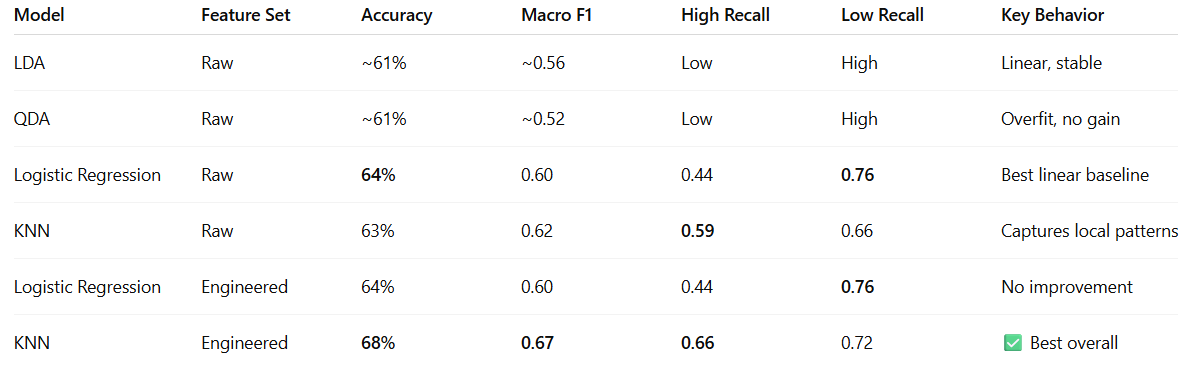


## 🧠 Evolution of Insights (Model by Model)
🔹 1. LDA (Linear Discriminant Analysis)
Established a linear separability baseline
Showed:
Low-quality wines are well-clustered
Medium & high overlap heavily

👉 Insight:

The dataset has a quality gradient, not clean class boundaries

🔹 2. QDA (Quadratic Discriminant Analysis)
Introduced non-linear boundaries
Performance did not improve

👉 Insight:

Non-linearity alone does not solve the problem
→ Overlap > boundary complexity

🔹 3. Logistic Regression (Raw Features)
Best performing linear model (64%)
Stable and interpretable

👉 Insight:

Problem is largely linear, but limited by class overlap
Medium class confirmed as a transition zone

🔹 4. KNN (Raw Features)
Slightly lower accuracy (63%)
Improved:
High-class detection
Medium-class balance

👉 Insight:

Local patterns exist, but:

Not strong enough to outperform global structure
Trade-off between class performance
🔹 5. Logistic Regression (Engineered Features)
No improvement over raw features

👉 Insight:

Feature engineering alone doesn’t help linear models
→ Relationships are not globally linear

🔹 6. KNN (Engineered Features) ✅ BEST MODEL
Accuracy jumped to 68%
Balanced improvement across all classes:
High recall ↑
Medium stability ↑
Low still strong

👉 Insight:

Feature engineering improved feature space geometry, and KNN leveraged it effectively

🔥 Key Learnings (Most Important Part)
1. The Real Bottleneck

❗ The problem is not just model choice
❗ It is class overlap + representation

Medium class = transition zone
High vs Medium = major confusion region
2. Linear vs Non-Linear Models
Linear models (LDA, Logistic):
Strong baseline
Stable but limited
Non-linear model (KNN):
Captures local structure
Needs good features to shine
3. Feature Engineering Impact
No effect on Logistic Regression
Major improvement for KNN

👉 Insight:

Engineered features introduced non-linear relationships, not usable by linear models but exploitable by KNN

4. Trade-Off Discovery

You discovered a key ML principle:

“Improving one class often comes at the cost of another.”

Logistic → strong low-class detection
KNN → better high-class detection
🧠 Final Conclusion

The best performance (68%) was achieved using KNN with engineered features, demonstrating that:

The dataset benefits from local, non-linear modeling
Feature engineering plays a critical role in reshaping the problem space
Class overlap remains a limiting factor, but can be partially mitigated
🚀 Final Takeaway (Portfolio-Level Insight)

